# Introduction

The shortest path to a probability, and the conventions the rest of these notebooks assume.

Mag$\nu$s computes neutrino oscillation probabilities by the **Magnus expansion**: the evolution operator over a slab is $\exp(\Omega)$, with $\Omega$ built from time-ordered integrals of nested commutators of the Hamiltonian. Truncating the series is exactly unitary at any order, which is the property that makes it worth doing this way rather than exponentiating a discretised Hamiltonian.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.magnus as magnus
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.globaldefs as gd
import magnus.plotting as plotting

To compute neutrino oscillation proabilities, Mag$\nu$s needs only three ingredients: 
* a Hamiltonian (`H_func`), written in the flavor basis, as a function of neutrino position (or time),
* the initial neutrino position (or time, `t_ini`), and
* the final neutrino position (or time, `t_fin`).

In practice, in most scenarios the Hamiltonian depends on the neutrino energy, whose value we often vary, so the neutrino energy becomes effectively also a free parameter to vary.

Let us start by computing oscillation probabilities in vacuum in a two-neutrino system. Although the user can provide their own custom Hamiltonian, Mag$\nu$s conveniently provides a library of commonly used Hamiltonians for two-neutrino and three-neutrinos oscillations (and also for 3+1 and 3+2 systems, with one and two extra flavors, respectively).

All of them live in a single module, `magnus.hamiltonians`, which we import as

In [2]:
import magnus.hamiltonians as hamiltonians

We will use the two-neutrino Hamiltonian in vacuum, i.e.,

\begin{equation}
\mathbf{H}_{2\nu}^{\rm vac}
=
\mathbf{U}^T 
\left(
 \begin{array}{cc}
  \frac{\Delta m^2}{2E} & 0 \\
  0 & -\frac{\Delta m^2}{2E} \\
 \end{array}
\right)
\mathbf{U} \;,
\end{equation}

where the mixing matrix, $\mathbf{U}$, is parametrized by a single mixing angle, $\theta$, i.e.,

\begin{equation}
 \mathbf{U}
 =
 \left(
  \begin{array}{cc}
   \cos\theta  & \sin\theta \\
   -\sin\theta & \cos\theta
  \end{array}
 \right) \;.
\end{equation}

We need values for the oscillation parameters $\theta$ and $\Delta m^2$.  Users can provide any values they wish.  For this example, we will shows oscillations between $\nu_e$ and $\nu_mu$, and use central values of the $\theta_{12}$ and $\Delta m_{21}^2$ parameters from the NuFit 6.0 global fit to oscillation data, which are predefined in the Mag$\nu$s globaldefs module, i.e.,

In [3]:
import magnus.globaldefs as gd

sth = gd.S12_NO_BF_NUFIT_6_0 # sin(theta) [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

Let's compute the probability for a baseline of 10 km and an energy of 1 MeV.

In [4]:
baseline = 10.*gd.UNIT_KM # 10 km natural units [eV^{-1}]
energy = 1.*gd.UNIT_MEV # [eV]

And now we define our Hamiltonian, as a function of neutrino position (`l`) and energy (`energy`).  In this case, the dependence on neutrino position is a dummy dependence, since the Hamiltonian in vacuum is position-independent. However, Mag$\nu$s expects a position-dependent Hamiltonian in general.

In [5]:
hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2)

array([[-7.19040000e-12,  1.72894122e-11],
       [ 1.72894122e-11,  7.19040000e-12]])

The oscillation probabilities are computed using the `osc_prob` function of the `oscprob` module, already imported above. Alongside it, `oscprobstd` provides the textbook closed-form expressions, which we will use throughout as an independent check on the Magnus result:

In [6]:
import magnus.oscprobstd as oscprobstd

Internally, the `osc_prob` function performs Magnus expansion to compute the evolution of the neutrino oscillation amplitude from `t_ini` to `t_fin` by partitioning this interval into subintervals, computing the evolution operator inside each subinterval, and performing their time-ordered product. The user manipulates the options of the Magnus expansion indirectly, via parameters passed to osc_prob.

(Users interested in using Mag$\nu$s to compute the Magnus expansion of an arbitrary matrix exponential, not only in neutrino oscillations, should look at the notebook `10_magnus_matrix_exponential.ipynb`.)

The `osc_prob` function computes probabilities for *any* number of neutrino flavors.  If it is fed a $2 \times 2$ Hamiltonian, then it will return probabilities for a two-neutrino system; if it is fed a $3 \times 3$ Hamiltonian, it will return probabilities for a three-neutrino system, *etc*.

We call `osc_prob` to compute the probability from `t_ini = 0.0` to `t_fin = baseline`. We pass `verbose = 2` to see run information and warnings:

In [7]:
P = oscprob.osc_prob(hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2), 0.0, baseline, verbose=2)
P

.----------------------------------------.
|   __  __                               |
|  |  \/  | __ _  __ _ _ __  _   _ ___   |
|  | |\/| |/ _` |/ _` | '_ \| | | / __|  |
|  | |  | | (_| | (_| | | | | |_| \__ \  |
|  |_|  |_|\__,_|\__, |_| |_|\__,_|___/  |
|                |___/                   |
'----------------------------------------'
Version: 1.0.0rc1 | Author(s): Mauricio Bustamante

Parameters passed to function magnus.osc_prob in this run:
   H_func = constant (time-independent)
   t_ini = 0.0
   t_fin = 50677300000.0
   n_slabs = 1
   n_tpts_per_slab = 2
   t_slab_edges = None
   magnus_exp_order = 4
   n_jobs = 1
   integration_method = gl
   rtol = 0.001
   atol = 0.001
   growth_factor_n_slabs = 1.5
   growth_factor_n_tpts_per_slab = 1.0
   max_num_loops = 50
   min_n_slabs = 1
   max_n_slabs = 20000
   min_n_tpts_per_slab = 2
   max_n_tpts_per_slab = 2
   validate_input = True
   save_log = False
   filename_log = ./out.log
   new_recursion_limit = 5000
   verbose = 2



array([[0.43678029, 0.56321971],
       [0.56321971, 0.43678029]])

The function `osc_prob` returns a symmetric probability matrix,
\begin{equation}
 \mathbf{P}_{2\nu}
 =
 \left(
  \begin{array}{cc}
   P_{ee}    & P_{e\mu} \\
   P_{\mu e} & P_{\mu\mu}
  \end{array}
 \right) \;,
\end{equation}
where $P_{\mu e} = P_{e \mu}$.

We can select individual probabilities using flavor indices predefined in the `globaldefs` module.  I.e., for $\nu_e \to \nu_e$,

In [8]:
P[gd.NUE][gd.NUE]

0.4367802885331581

and, for $\nu_e \to \nu_\mu$,

In [9]:
P[gd.NUE][gd.NUMU]

0.5632197114668426

Notice that in the run above we had a warning.  This is because we passed a constant (*i.e.*, time-independent) Hamiltonian to `osc_prob`.  In cases like that (*i.e.*, in vacuum or constant-density matter), the only nonzero term of the Magnus expansion is the first one. *I.e.*, the evolution operator is simply $e^{-i H L}$, with $L = t_{\rm fin}-t_{\rm ini}$).  When a constant Hamiltonian is passed to `osc_prob` this is identified and the run parameters are adjusted to use first-order Magnus expansion, for speed-up.

An alternative way to compute the same probability matrix is to define a vacuum Hamiltonian function of position of neutrino position (`l`) and neutrino energy (`energy`), with the dependence on position merely dummy, since the vacuum Hamiltonian is time-independent:

In [10]:
def H_2nu_vac(l, energy):
    return hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2)

In this case, we need to pass a Hamiltonian that is a function *only* of position:

In [11]:
oscprob.osc_prob(lambda l: H_2nu_vac(l, energy), 0.0, baseline, magnus_exp_order=1, n_slabs=1, n_tpts_per_slab=2, rtol=None, atol=None)

array([[0.43678029, 0.56321971],
       [0.56321971, 0.43678029]])

The resulting probability matrix is the same as before, but we had to manually set the run parameters to generate it with the same speed as when we simply passed the constant Hamiltonian `hamiltonian_2nu_vacuum(energy, sth, Dm2)` to `osc_prob`.  However, the recipe of defining a position-dependent Hamiltonian and passing it to `osc_prob` will be at the core of later calculations of probabilities for time-*dependent* Hamiltonians.

For convenience, Mag$\nu$s includes a wrapper to return the probability matrix in vacuum for given values of the oscillation parameters, the neutrino baseline, and the neutrino energy, bypassing the more lengthy procedure above:

In [12]:
oscprob.osc_prob_2nu_vacuum(energy, baseline, sth, Dm2)

array([[0.43678029, 0.56321971],
       [0.56321971, 0.43678029]])

This function can also return the probability matrices for multiple energies and baselines, passed to it either as lists of NumPy arrays. Internally, it will `zip` energy and baseline arrays (*i.e.*, (`zip(energy, L)`), compute the probability matrix for each element of the zip object, and return a NumPy array containing all of the matrices, in the `zip` order. This means that the lengths of the provided energy and baseline arrays should be equal, and that the length of the returned array will also be equal to that.  For example,

In [13]:
prob = oscprob.osc_prob_2nu_vacuum(gd.UNIT_MEV*np.array([1.0, 10.0]), [baseline, baseline], sth, Dm2)
prob

array([[[0.43678029, 0.56321971],
        [0.56321971, 0.43678029]],

       [[0.99234609, 0.00765391],
        [0.00765391, 0.99234609]]])

And from this we can select the probability channel we are interested, say $\nu_e \to \nu_\mu$,

In [14]:
prob[:,gd.NUE,gd.NUMU]

array([0.56321971, 0.00765391])

We one can directly ask `osc_prob_2nu_vacuum` to return only that probability by passing the initial and final flavors, `nu_i` and `nu_f` (which reduces memory requirements).

If `energy` and `L` as floats, the probability is returned as a float.

In [15]:
oscprob.osc_prob_2nu_vacuum(gd.UNIT_MEV*1.0, baseline, sth, Dm2, nu_i=gd.NUE, nu_f=gd.NUMU)

0.5632197114668426

If `energy` is a float and `L` is a list (or NumPy array) with multiple entries, `osc_prob_2nu_vacuum` returns an array with the probability computed for that fixed `energy` and each value inside `L`:

In [16]:
oscprob.osc_prob_2nu_vacuum(gd.UNIT_MEV*1.0, gd.UNIT_KM*np.array([1.0, 10.0, 100.0, 1000.0]), sth, Dm2, nu_i=gd.NUE, nu_f=gd.NUMU)

array([0.00765391, 0.56321971, 0.00354698, 0.30852379])

Conversely, we can pass a single value of `L` and multiple values of `E` to `osc_prob_2nu_vacuum` and it will return the probability computed for that fixed `L` and each value inside `energy`:

In [17]:
oscprob.osc_prob_2nu_vacuum(gd.UNIT_MEV*np.array([1.0, 5.0, 10.0, 100.0]), baseline, sth, Dm2, nu_i=gd.NUE, nu_f=gd.NUMU)

array([5.63219711e-01, 3.03407867e-02, 7.65391143e-03, 7.67669624e-05])

The same functionality is available in the functions `osc_prob_2nu_matter_constant_density`, `osc_prob_3nu_vacuum`, and `osc_prob_3nu_matter_constant_density` that we introduce later.

Let's now move on to three-neutrino oscillations.  No new import is needed: the three-neutrino Hamiltonians come from the same `magnus.hamiltonians` module imported above, and are named `hamiltonian_3nu_*` rather than `hamiltonian_2nu_*`.  For instance:

In [18]:
# The 3nu builders sit alongside the 2nu ones in the same module
[n for n in hamiltonians.__all__ if n.startswith('hamiltonian_3nu')][:5]

['hamiltonian_3nu_vacuum_energy_independent',
 'hamiltonian_3nu_vacuum_energy_independent_td',
 'hamiltonian_3nu_vacuum',
 'hamiltonian_3nu_vacuum_td',
 'hamiltonian_3nu_matter']

The vacuum Hamiltonian is now a $3 \times 3$ matrix, i.e.,
\begin{equation}
 \mathbf{H}_{3\nu}^{\rm vac}
 =
 \mathbf{U}_{\rm PMNS}^\dagger
 \left(
  \begin{array}{ccc}
   0 & 0 & 0 \\
   0 & \frac{\Delta m_{21}^2}{2E} & 0 \\
   0 & 0 & \frac{\Delta m_{31}^2}{2E}
  \end{array}
 \right)
 \mathbf{U}_\textrm{PMNS} \;,
\end{equation}
where $\mathbf{U}_{\rm PMNS}$ is the complex-valued Pontecorvo-Maki-Nakagawa-Sakata (PMNS) matrix, parametrized using three mixing angles, $\theta_{12}$, $\theta_{23}$, and $\theta_{13}$, and one CP-violation phase, $\delta_{\rm CP}$.

Like before, for this example we set the values of the oscillation parameters to their central values from NuFit 6.0, *i.e.*,

In [19]:
s12 = gd.S12_NO_BF_NUFIT_6_0 # sin(theta_12) [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # sin(theta_23) [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # sin(theta_13) [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [radian]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

We compute the probabilities by calling `osc_prob` again. This time, we set `verbose = 1` to only show warnings and important messages:

In [20]:
P = oscprob.osc_prob(hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31), 0.0, baseline, verbose=1)
P

array([[0.44464666, 0.29867235, 0.25668099],
       [0.25107128, 0.63934947, 0.10957925],
       [0.30428206, 0.06197818, 0.63373976]])

In this case, the result is the probability matrix
\begin{equation}
 \mathbf{P}_{3\nu}
 =
 \left(
  \begin{array}{ccc}
   P_{ee}     & P_{e\mu}    & P_{e\tau} \\
   P_{\mu e}  & P_{\mu\mu}  & P_{\mu\tau} \\
   P_{\tau e} & P_{\tau\mu} & P_{\tau\tau}
  \end{array}
 \right) \;,
\end{equation}
where $P_{\alpha \beta} = P_{\beta \alpha}$, with $\alpha, \beta = e, \mu, \tau$.

We can retrieve probabilities for specific channels using flavor indices, as before, *e.g.*,

In [21]:
P[gd.NUE][gd.NUE]

0.4446466606016046

In [22]:
P[gd.NUE][gd.NUMU]

0.29867235336419606

In [23]:
P[gd.NUMU][gd.NUMU]

0.6393494679347734

In [24]:
P[gd.NUMU][gd.NUTAU]

0.10957925492166845

Similarly to the two-neutrino case, for convenience, Mag$\nu$s contains a wrapper for the calculation of the three-neutrino probability in vacuum for given values of the oscillation parameters, neutrino position, and neutrino energy:

In [25]:
oscprob.osc_prob_3nu_vacuum(energy, baseline, s12, s23, s13, dCP, D21, D31)

array([[0.44464666, 0.29867235, 0.25668099],
       [0.25107128, 0.63934947, 0.10957925],
       [0.30428206, 0.06197818, 0.63373976]])

And, like before, we can call this function also with an array of energies and baselines, *e.g.*,

In [26]:
prob = oscprob.osc_prob_3nu_vacuum(gd.UNIT_MEV*np.array([1.0, 10.0]), [baseline, baseline], s12, s23, s13, dCP, D21, D31)
prob

array([[[4.44646661e-01, 2.98672353e-01, 2.56680986e-01],
        [2.51071277e-01, 6.39349468e-01, 1.09579255e-01],
        [3.04282062e-01, 6.19781787e-02, 6.33739759e-01]],

       [[9.92500656e-01, 3.72444056e-03, 3.77490363e-03],
        [3.66457973e-03, 9.95723641e-01, 6.11779108e-04],
        [3.83476446e-03, 5.51918279e-04, 9.95613317e-01]]])

And we can select to return only the channel we are interested, say $\nu_e \to \nu_\mu$,

In [27]:
oscprob.osc_prob_3nu_vacuum(gd.UNIT_MEV*np.array([1.0, 10.0]), [baseline, baseline], s12, s23, s13, dCP, D21, D31,
                            nu_i=gd.NUE, nu_f=gd.NUMU)

array([0.29867235, 0.00372444])

If the vacuum probability needs to computed for many values of energy and baseline, it is more computationally efficient to call `osc_prob_3nu_vacuum` once with the array of energies and baselines at which it must be computed than calling it multiple times, each for a different value of energy and baseline.  The reason is that, internally, `osc_prob_3nu_vacuum` has an overhead that is the same regardless if it is computed for one or multiple probability computations.

Also, `osc_prob_3nu_vacuum` can be called without passing values for any of the oscillation parameters; this is useful if we just want to quickly a probability.  If so, internally, the function will assign them values from a default parameter set in Mag$\nu$s, which is set to a recent experimental determination.  Let's call `osc_prob_3nu_vacuum` with `verbose = 1` to see a warning when parameters are assigned default values:

In [28]:
oscprob.osc_prob_3nu_vacuum(gd.UNIT_MEV*np.array([1.0, 10.0]), baseline, 
                            nu_i=gd.NUE, nu_f=gd.NUMU, verbose=1)

s12 = 0.5549774770204643
s23 = 0.6855654600401044
s13 = 0.14882876066137216
dCP = 3.7000980142279785 rad
D21 = 7.49e-05 eV^2
D31 = 0.002513 eV^2





array([0.29867235, 0.00372444])

We can also specify only some of the oscillation parameter values, and let `osc_prob_3nu_vacuum` set the unspecified parameters to their default values, *e.g.*,

In [29]:
oscprob.osc_prob_3nu_vacuum(gd.UNIT_MEV*np.array([1.0, 10.0]), baseline, s13=0.0, dCP=0.0, D31=0.0,
                            nu_i=gd.NUE, nu_f=gd.NUMU, verbose=1)

s12 = 0.5549774770204643
s23 = 0.6855654600401044
D21 = 7.49e-05 eV^2





array([0.29850645, 0.00405657])

Finally, by passing the argument `default_osc_params_set_name` we can specifiy which parameter data set should be used by `osc_prob_3nu_vacuum` as the default from which to assign values to the unspecified parameters.  We can print the list of available predefined parameter set names via

In [30]:
list(gd.OSC_PARAMS_PREDEFINED.keys())

['OSC_PARAMS_DEFAULT',
 'OSC_PARAMS_NU_FIT_6_0_SK_NO',
 'OSC_PARAMS_NU_FIT_6_0_SK_IO']

And the current default set is

In [31]:
gd.OSC_PARAMS_PREDEFINED['OSC_PARAMS_DEFAULT']

{'name': 'OSC_PARAMS_NU_FIT_6_0_NO',
 'description': 'NuFit 6.0, NO, with SK atmospheric data',
 's12': 0.5549774770204643,
 's23': 0.6855654600401044,
 's13': 0.14882876066137216,
 'dCP': 3.7000980142279785,
 'D21': 7.49e-05,
 'D31': 0.002513}

For instance, we could choose to use instead NuFit 6.0 with inverted mass ordering (IO), with SK atmospheric data:

In [32]:
oscprob.osc_prob_3nu_vacuum(gd.UNIT_MEV*np.array([1.0, 10.0]), baseline, 
                            nu_i=gd.NUE, nu_f=gd.NUMU, default_osc_params_set_name='OSC_PARAMS_NU_FIT_6_0_SK_IO', verbose=1)

s12 = 0.5549774770204643
s23 = 0.7416198487095663
s13 = 0.14936532395439042
dCP = 4.782202150464463 rad
D21 = 7.49e-05 eV^2
D31 = -0.0024091 eV^2





array([0.27857859, 0.00365989])

Let's now vary the baseline and energy and plot the two- and three-neutrino $\nu_e \to \nu_\mu$ probabilities.  We will stick to using the default oscillation parameter set values from now on in this notebook.

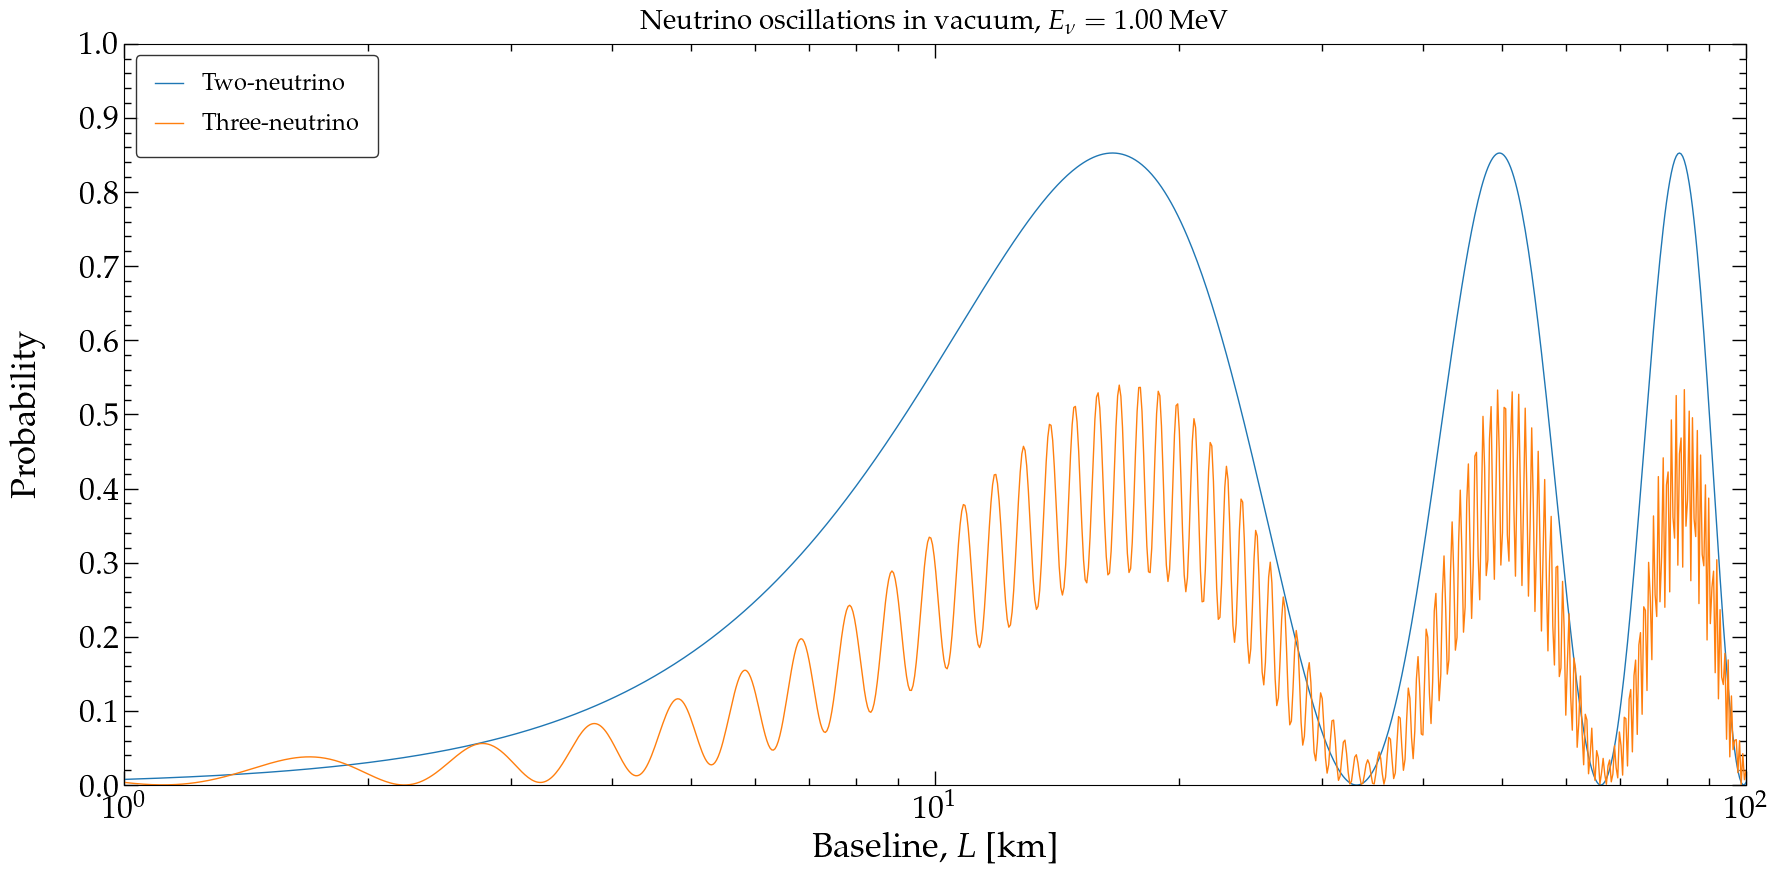

In [33]:
nu_i, nu_f = gd.NUE, gd.NUMU
npts = 1000
energy = 1.0*gd.UNIT_MEV # [eV]
baseline_arr = np.logspace(0.0, 2.0, npts) # [km]

# Both wrappers take the whole array of baselines in one call. Looping over
# `baseline_arr` and calling them once per point would give the same answer at
# roughly twenty-five times the cost -- the entry path (validation, Hamiltonian
# probing, dispatch) is paid per call, not per point.
prob_2nu_vacuum_vs_baseline = oscprob.osc_prob_2nu_vacuum(energy, gd.UNIT_KM*baseline_arr, s12, D21, nu_i=nu_i, nu_f=nu_f)
prob_3nu_vacuum_vs_baseline = oscprob.osc_prob_3nu_vacuum(energy, gd.UNIT_KM*baseline_arr, nu_i=nu_i, nu_f=nu_f)

fig, ax = plotting.plot_probability_vs_baseline(
    baseline_arr,
    [dict(y=prob_2nu_vacuum_vs_baseline, label=r'Two-neutrino'),
     dict(y=prob_3nu_vacuum_vs_baseline, label=r'Three-neutrino')],
    ylabel=r'Probability',
    xlim=(baseline_arr[0], baseline_arr[-1]),
    legend_loc='upper left',
    title=r'Neutrino oscillations in vacuum, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV))

## Figures without the boilerplate

The plot above is short because it is a simple one. Most figures in these
notebooks are not: the standard shape -- a set of curves over a short panel
showing the relative error against a reference -- takes about thirty lines of
`gridspec_kw`, tick locators, legend keywords and axis wrangling, and notebooks
`02` and `03` each repeat it fourteen times.

That boilerplate is what `magnus.plotting` packages up. It is worth seeing the
before and after side by side, because the point is not that the figure gets
better -- it is that the figure stays *exactly the same* while the code
collapses.

First, the hand-built version, written out in full:

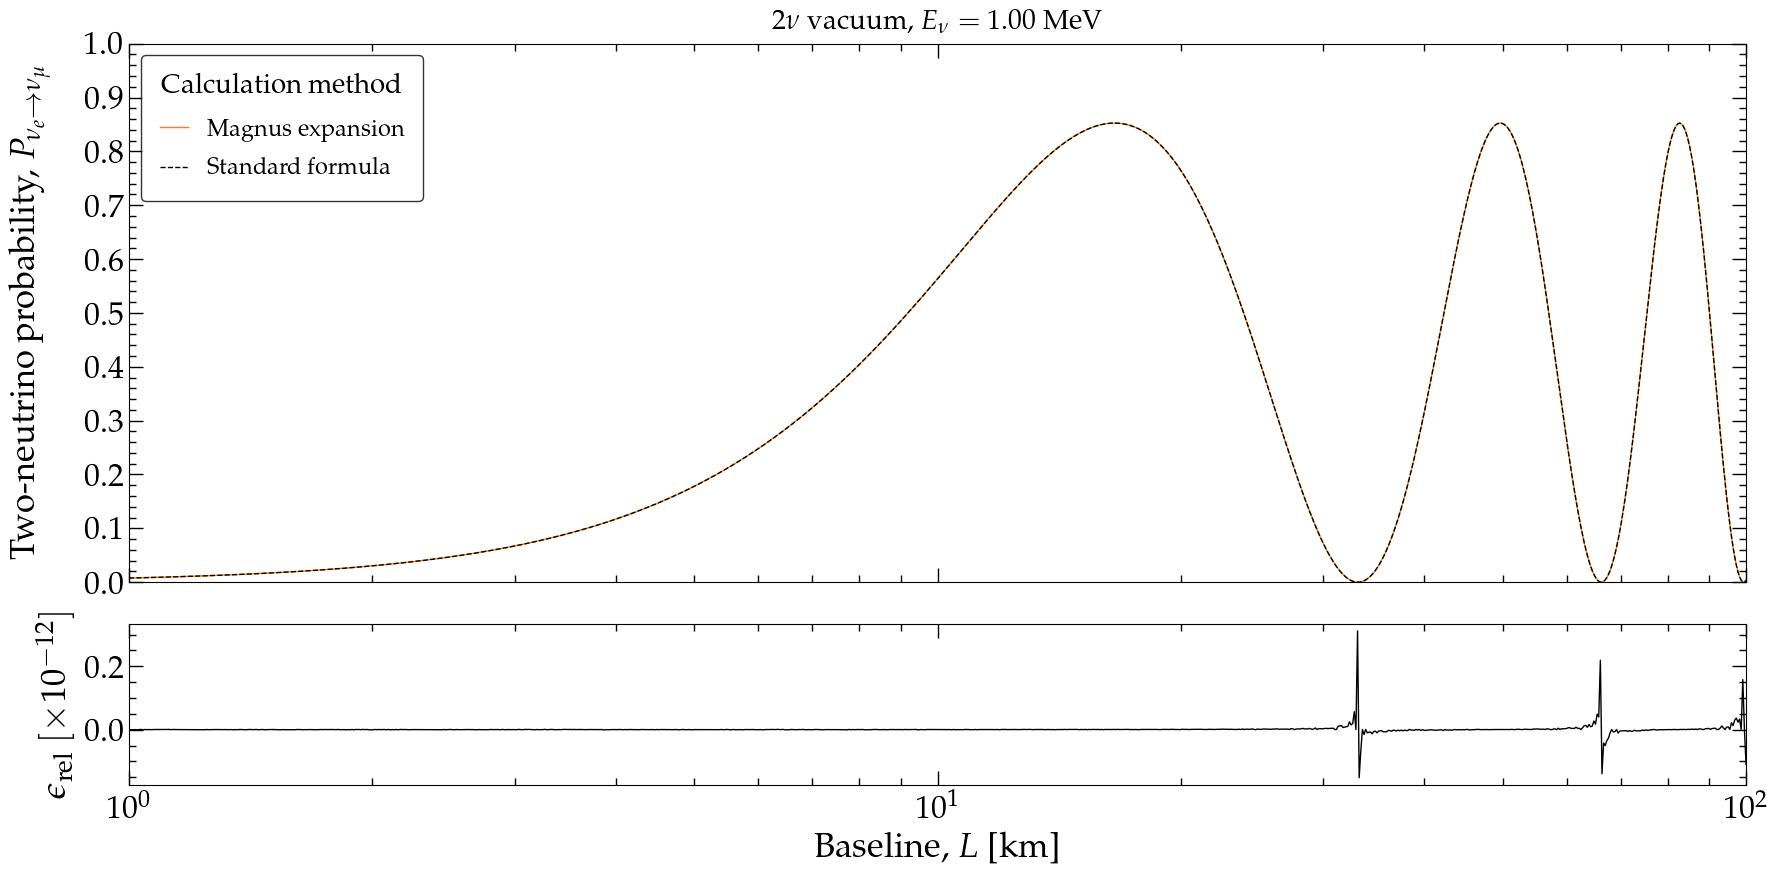

In [34]:
# Two ways of computing the same two-neutrino probability, so that the lower
# panel has something to compare: the Magnus engine against the closed form.
prob_magnus = oscprob.osc_prob_2nu_vacuum(energy, gd.UNIT_KM*baseline_arr, s12, D21,
                                          nu_i=nu_i, nu_f=nu_f)
prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(s12, D21, energy,
                                                        gd.UNIT_KM*l)[nu_i][nu_f]
                     for l in baseline_arr])
residual = (prob_magnus - prob_std)/np.maximum(np.abs(prob_std), 1.e-300)/1.e-12

# ---- the hand-built figure: this is the block that gets copied around -------
heights = [1.0, 0.3]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1,
    nrows=2,
    gridspec_kw=gs_kw,
    figsize=[18, 9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

ax[0].plot(baseline_arr, prob_magnus, lw=1, color='C1', ls='-', label='Magnus expansion')
ax[0].plot(baseline_arr, prob_std, lw=1, color='k', ls='--', label='Standard formula')
ax[1].plot(baseline_arr, residual, lw=1, color='k', ls='-')

ax[0].legend(fontsize=17, frameon=True, loc='upper left', handlelength=1.2,
             handleheight=0.7, borderpad=0.8, title_fontsize=20, edgecolor='k',
             labelspacing=0.7, ncol=1, title=r'Calculation method')

ax[0].set_ylabel(r'Two-neutrino probability,~'+r'$P_{\nu_e \to \nu_\mu}$', labelpad=25)
ax[0].set_xlim(baseline_arr[0], baseline_arr[-1])
ax[0].set_ylim(0, 1)
ax[0].set_xscale('log')
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[0].xaxis.set_ticklabels([])
ax[1].set_xlabel(r'Baseline, $L$ [km]')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}~[\times 10^{-12}]$', labelpad=7)
ax[1].set_xscale('log')
ax[1].set_xlim(baseline_arr[0], baseline_arr[-1])
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.20))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.05))
ax[0].set_title(r'$2\nu$~vacuum, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
                fontsize=20, pad=10)

plt.tight_layout()

Thirty-one lines, of which exactly three carry any physics.

Now the same figure, in one call:

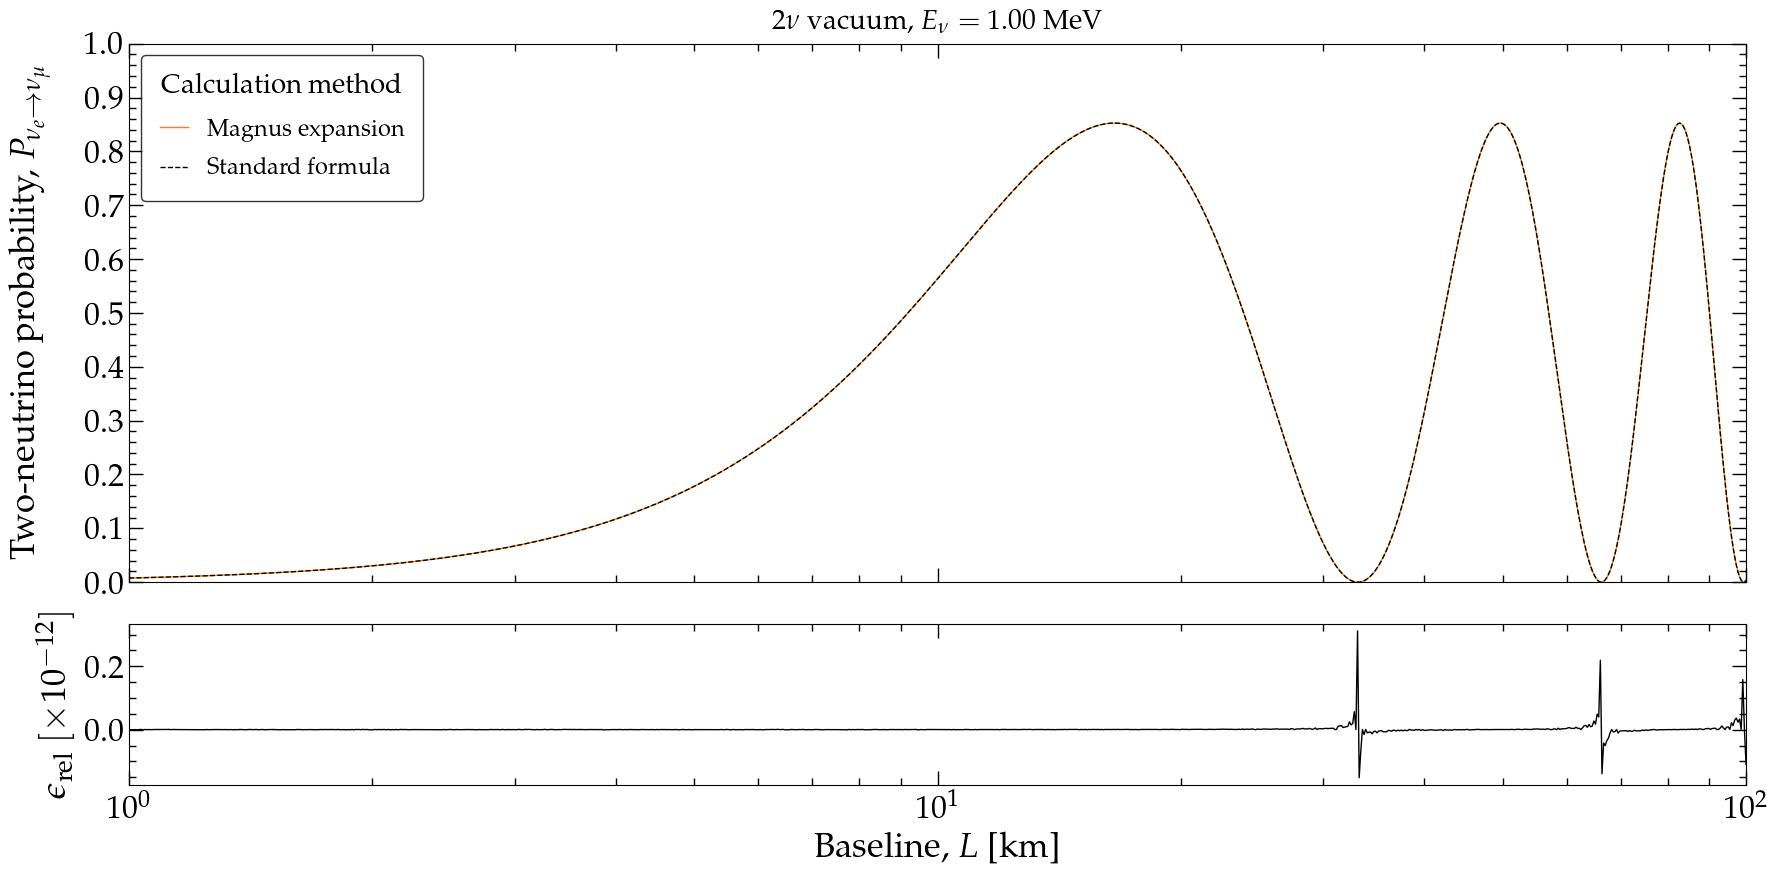

In [35]:
from magnus.plotting import plot_curves, prob_label

fig, ax = plot_curves(
    baseline_arr,
    [dict(y=prob_magnus, label='Magnus expansion', color='C1'),
     dict(y=prob_std, label='Standard formula', color='k', ls='--')],
    xlabel=r'Baseline, $L$ [km]',
    ylabel=r'Two-neutrino probability,~'+prob_label(nu_i, nu_f),
    xlim=(baseline_arr[0], baseline_arr[-1]), ylim=(0, 1), xscale='log',
    ymajor=0.10, yminor=0.02,
    residual=residual, residual_label=r'$\epsilon_{\rm rel}~[\times 10^{-12}]$',
    residual_ymajor=0.20, residual_yminor=0.05,
    legend_title=r'Calculation method', legend_loc='upper left',
    title=r'$2\nu$~vacuum, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
)

The defaults are the house style, so nothing had to be restated: the figure
size, the two-panel height ratio, the nine legend keywords, the suppressed
tick labels on the upper panel, and the shared abscissa limits all come for
free. What is left in the call is what actually differs between figures.

`plot_curves` returns `(fig, ax)` precisely so that it is a starting point and
not a dead end -- anything Matplotlib can do to an axes can still be done
afterwards. The rest of this notebook, and all the others, use these functions;
see the [plotting page](https://mbustama.github.io/Magnus/plotting.html) for
the full set, which also covers density-profile stacks, bi-probability planes
and oscillograms.

One install note: Matplotlib is an optional dependency, so plotting needs
`pip install 'magnuspy[plot]'` (or `pip install -e '.[plot]'` from a checkout).
The engine itself needs only NumPy, SciPy and joblib.

We can also plot probabilities *vs.* energy, say, for a fixed baseline of 100 km:

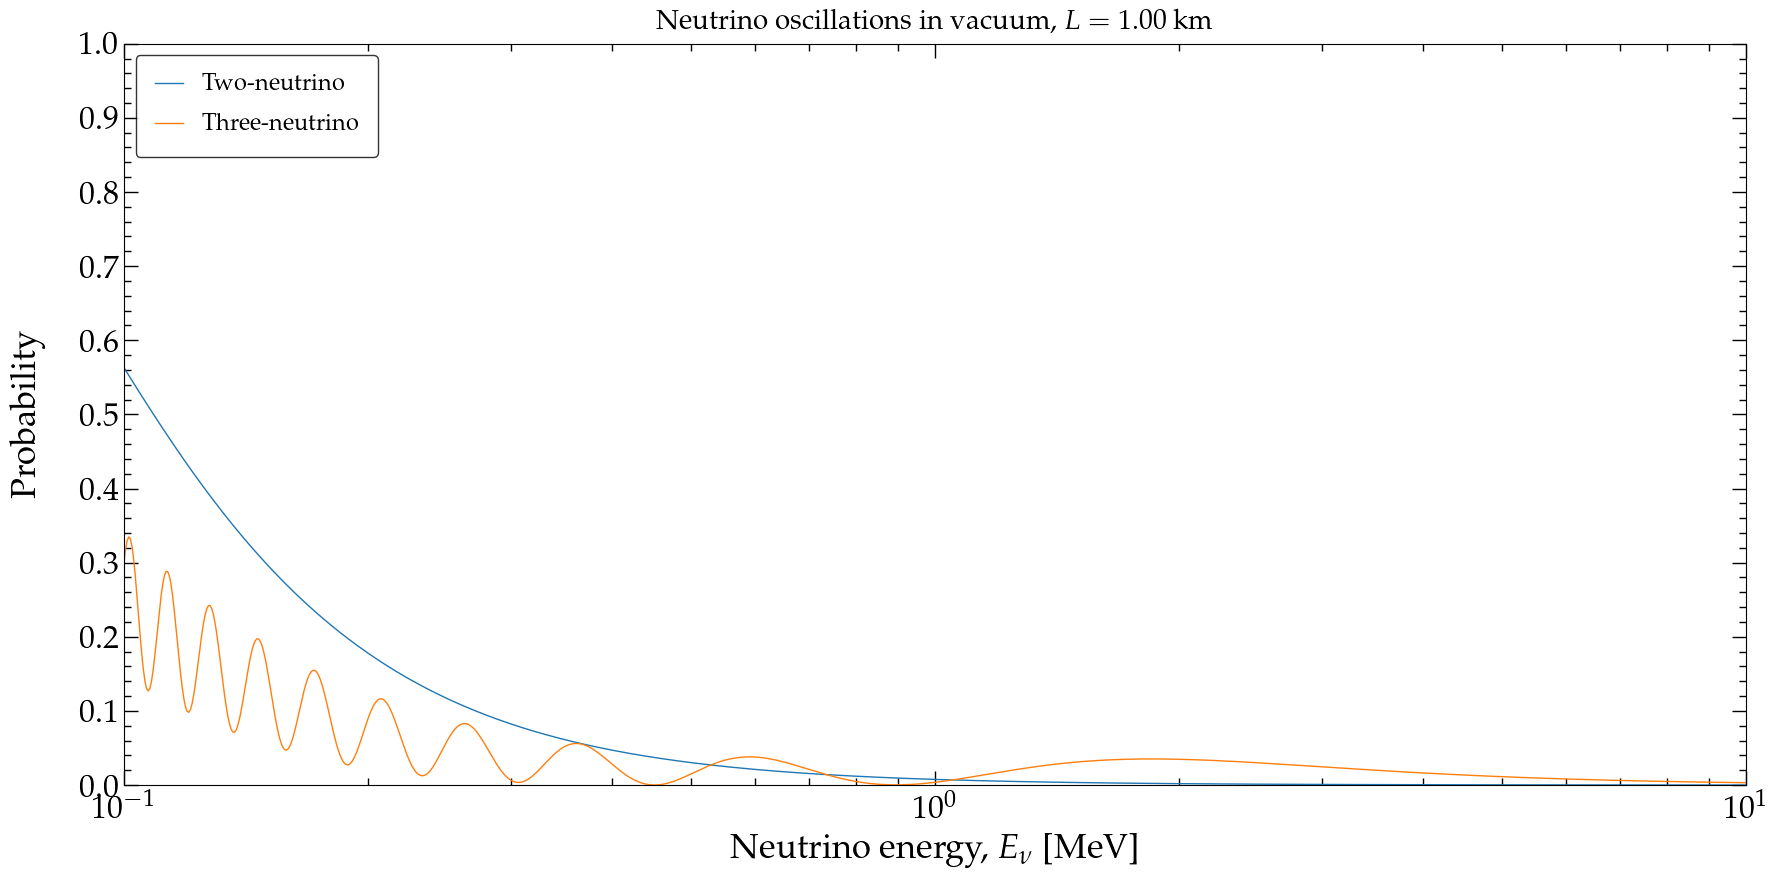

In [36]:
nu_i, nu_f = gd.NUE, gd.NUMU
npts = 1000
baseline = 1.0*gd.UNIT_KM # [eV^-1]
energy_arr = np.logspace(-1.0, 1.0, npts) # [MeV]

prob_2nu_vacuum_vs_energy = oscprob.osc_prob_2nu_vacuum(gd.UNIT_MEV*energy_arr, baseline, s12, D21, nu_i=nu_i, nu_f=nu_f)
prob_3nu_vacuum_vs_energy = oscprob.osc_prob_3nu_vacuum(gd.UNIT_MEV*energy_arr, baseline, nu_i=nu_i, nu_f=nu_f)

fig, ax = plotting.plot_probability_vs_energy(
    energy_arr,
    [dict(y=prob_2nu_vacuum_vs_energy, label=r'Two-neutrino'),
     dict(y=prob_3nu_vacuum_vs_energy, label=r'Three-neutrino')],
    energy_unit='MeV', ylabel=r'Probability',
    xlim=(energy_arr[0], energy_arr[-1]),
    legend_loc='upper left',
    title=r'Neutrino oscillations in vacuum, $L = $~{:.2f}~km'.format(baseline/gd.UNIT_KM))

Now let's add matter effects.  To do this, we need to add a new contribution to the Hamiltonian that contributes the potential due to the coherent forward scattering of $\nu_e$ on electrons, $V_{\rm CC}$, *i.e.*,
\begin{equation}
 H_{3\nu}^{\rm matt}
 = 
 \left(
  \begin{array}{ccc}
   V_{\rm CC} & 0 & 0 \\
   0 & 0 & 0 \\
   0 & 0 & 0 
  \end{array}
 \right) \;.
\end{equation}
With this, the total Hamiltonian becomes
\begin{equation}
 H_{3\nu} = H_{3\nu}^{\rm vac} + H_{3\nu}^{\rm matt} \;.
\end{equation}
The potential $V_{\rm CC} = \sqrt{2} G_F N_e$ varies proportionally to the electron number densit, $N_e$.

In [37]:
rho = 10*gd.UNIT_G_PER_CM3 # [g cm^{-3}]

which is roughly the density at the center of the Earth.

To compute the potential given the matter density, we will need a few helper functions that are provied by Mag$\nu$s in the `matter` module, which we now import:

In [38]:
import magnus.matter as matter

First, we compute the electron number density using the `num_density_e_func` function.  This function can return the electron number density at any position given a varying matter density profile, which is why we need to pass `rho` as a position-dependent function, and evaluate at `l = 0.0` (any value of `l` will do, since `rho` is a constant).  We assume that the matter is isoscalar (*i.e.*, that the ratio of neutrons to protons is 1) and electrically neutral (*i.e.*, that the ratio of electrons to baryons, or the electron fraction, is 0.5):

In [39]:
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, 
                                          ratio_number_neutrons_to_protons=1.0, electron_fraction=0.5) # [eV^3]
num_density_e

22948286409.274246

With this, we compute the coherent forward potential using the `VCC_func` function.  Again, the function is designed to return the potential at any position given a varying electron number density profile, but we evaluate it at `l = 0`:

In [40]:
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # [eV]
VCC

3.785339524585256e-13

Now we can define the vacuum Hamiltonian, as before, and a constant matter contribution to the Hamiltonian using the predefined function `hamiltonian_3nu_matter`:

In [41]:
H_3nu_vac = hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31)
H_3nu_matt = hamiltonians.hamiltonian_3nu_matter(VCC)
H_3nu = H_3nu_vac + H_3nu_matt

And we call the `osc_prob` function to compute the probabilities:

In [42]:
oscprob.osc_prob(H_3nu, 0.0, baseline, verbose=1)

array([[9.92502573e-01, 3.74292602e-03, 3.75450096e-03],
       [3.68363317e-03, 9.95706803e-01, 6.09564244e-04],
       [3.81379381e-03, 5.50271401e-04, 9.95635935e-01]])

And, similarly to the two-neutrino case, for convenience, Mag$\nu$s contains a wrapper for the calculation of the three-neutrino probability in constant-density matter for given values of the oscillation parameters, neutrino position, and neutrino energy, and matter density (by default, it uses `ratio_number_neutrons_to_protons = 1.0` and `electron_fraction = 0.5`, but different values can be passed as optional arguments). Also, like for the three-neutrino case in vacuum (`osc_prob_3nu_vacuum`, see earlier in the notebook), we can choose not to pass values for the oscillation parameters, and let them be set to the default oscillation parameter data set in Mag$\nu$s (set `verbose = 1` to see a warning when this happens):

In [43]:
oscprob.osc_prob_3nu_matter_constant_density(energy, baseline, rho, verbose=1)

s12 = 0.5549774770204643
s23 = 0.6855654600401044
s13 = 0.14882876066137216
dCP = 3.7000980142279785 rad
D21 = 7.49e-05 eV^2
D31 = 0.002513 eV^2




array([[9.92502573e-01, 3.74292602e-03, 3.75450096e-03],
       [3.68363317e-03, 9.95706803e-01, 6.09564244e-04],
       [3.81379381e-03, 5.50271401e-04, 9.95635935e-01]])

(A similar function exists for the two-neutrino case, `osc_prob_2nu_matter_constant_density`.)

By default, this returns the probability for neutrinos.  To compute it for anti-neutrinos (which takes the complex-conjugate of the PMNS mixing matrix and flips the sign of $V_{\rm CC}$, the optional argument `nubar = True` must be passed.  For instance,

In [44]:
oscprob.osc_prob_3nu_matter_constant_density(energy, baseline, rho, nubar=True)

array([[9.92498600e-01, 3.64560221e-03, 3.85579777e-03],
       [3.70603171e-03, 9.95740402e-01, 5.53566586e-04],
       [3.79536827e-03, 6.13996087e-04, 9.95590636e-01]])

And, like for the vacuum case (`osc_prob_2nu_vacuum` and `osc_prob_3nu_vacuum`), we can pass arrays of energy and baseline to compute in one go, and select single probability channels to return.

In [45]:
oscprob.osc_prob_3nu_matter_constant_density(gd.UNIT_MEV*np.array([1.0, 5.0, 10.0, 100.0]), baseline, 
                                             rho, nu_i=gd.NUE, nu_f=gd.NUMU)

array([3.74292602e-03, 1.13343876e-02, 3.19398295e-03, 3.39681994e-05])

Let's now compare three-neutrino probability of $\bar{\nu}_e \to \bar{\nu}_\mu$ in vacuum and in matter for two choices of constant matter density.  First, we plot them *vs.* baseline:

Text(0.5, 1.0, '$3\\nu$  oscillations, $E_\\nu = $~1.00~MeV')

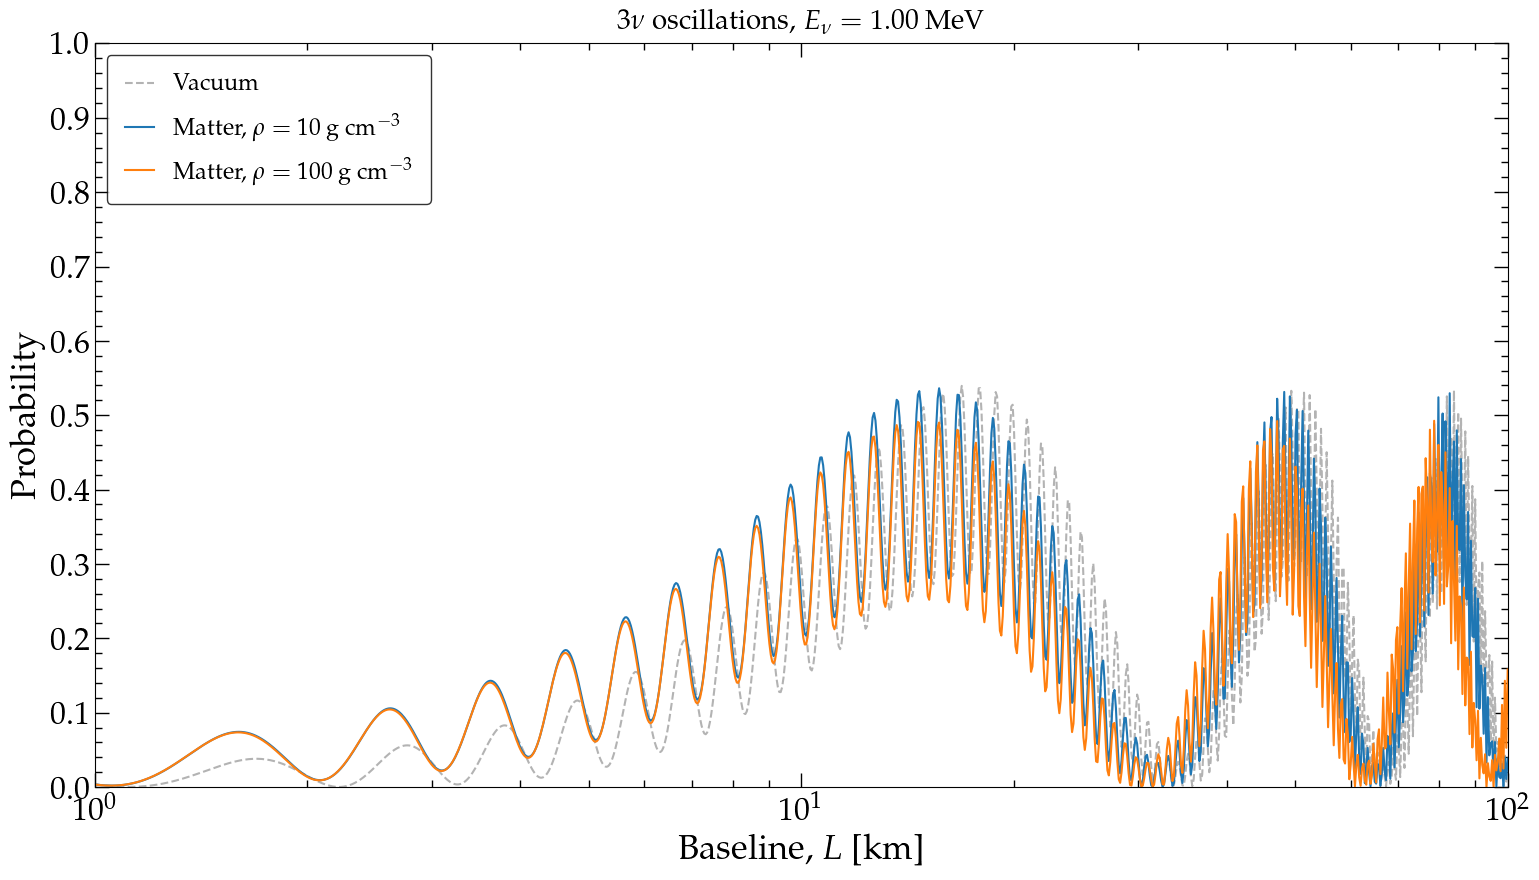

In [46]:
nu_i, nu_f = gd.NUE, gd.NUMU
npts = 1000
energy = 1.0*gd.UNIT_MEV # [eV]
baseline_arr = np.logspace(0.0, 2.0, npts) # [km]
rho_lo, rho_hi = 10*gd.UNIT_G_PER_CM3, 100*gd.UNIT_G_PER_CM3 # 10 and 100 g cm^{-3} in natural units [eV^4]

prob_3nu_matt_const_lo_vs_baseline = oscprob.osc_prob_3nu_matter_constant_density(energy, gd.UNIT_KM*baseline_arr, 
                                                                                  rho=rho_lo, nu_i=nu_i, nu_f=nu_f, nubar=True)
prob_3nu_matt_const_hi_vs_baseline = oscprob.osc_prob_3nu_matter_constant_density(energy, gd.UNIT_KM*baseline_arr, 
                                                                                  rho=rho_hi, nu_i=nu_i, nu_f=nu_f, nubar=True)

# This gives the same result, but it is less efficient (calling osc_prob_3nu_matter_constant_density has an overhead):
# prob_3nu_matt_const_lo_vs_baseline = [oscprob.osc_prob_3nu_matter_constant_density(energy, l, 
#                                                                                    rho=rho_lo, nubar=True)[nu_i][nu_f] 
#                                for l in gd.UNIT_KM*baseline_arr]
# prob_3nu_matt_const_hi_vs_baseline = [oscprob.osc_prob_3nu_matter_constant_density(energy, l, 
#                                                                                    rho=rho_hi, nubar=True)[nu_i][nu_f] 
#                                for l in gd.UNIT_KM*baseline_arr]

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=[18,9])
ax.plot(baseline_arr, prob_3nu_vacuum_vs_baseline, label=r'Vacuum', c='0.7', ls='--')
ax.plot(baseline_arr, prob_3nu_matt_const_lo_vs_baseline, label=r'Matter, $\rho = $~{:.0f}'.format(rho_lo/gd.UNIT_G_PER_CM3)+r'~g~cm$^{-3}$')
ax.plot(baseline_arr, prob_3nu_matt_const_hi_vs_baseline, label=r'Matter, $\rho = $~{:.0f}'.format(rho_hi/gd.UNIT_G_PER_CM3)+r'~g~cm$^{-3}$')
ax.legend(fontsize=17, frameon=True, loc='upper left', handlelength=1.2, handleheight=0.7, borderpad=0.8, 
          title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)
ax.set_xlabel(r'Baseline, $L$ [km]')
ax.set_ylabel(r'Probability')
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax.set_xlim(baseline_arr[0], baseline_arr[-1])
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.set_title(r'$3\nu$  oscillations, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=20, pad=10)

And now we plot the probabilities *vs.* energy:

Text(0.5, 1.0, '$3\\nu$ oscillations, $L = $~100.00~km')

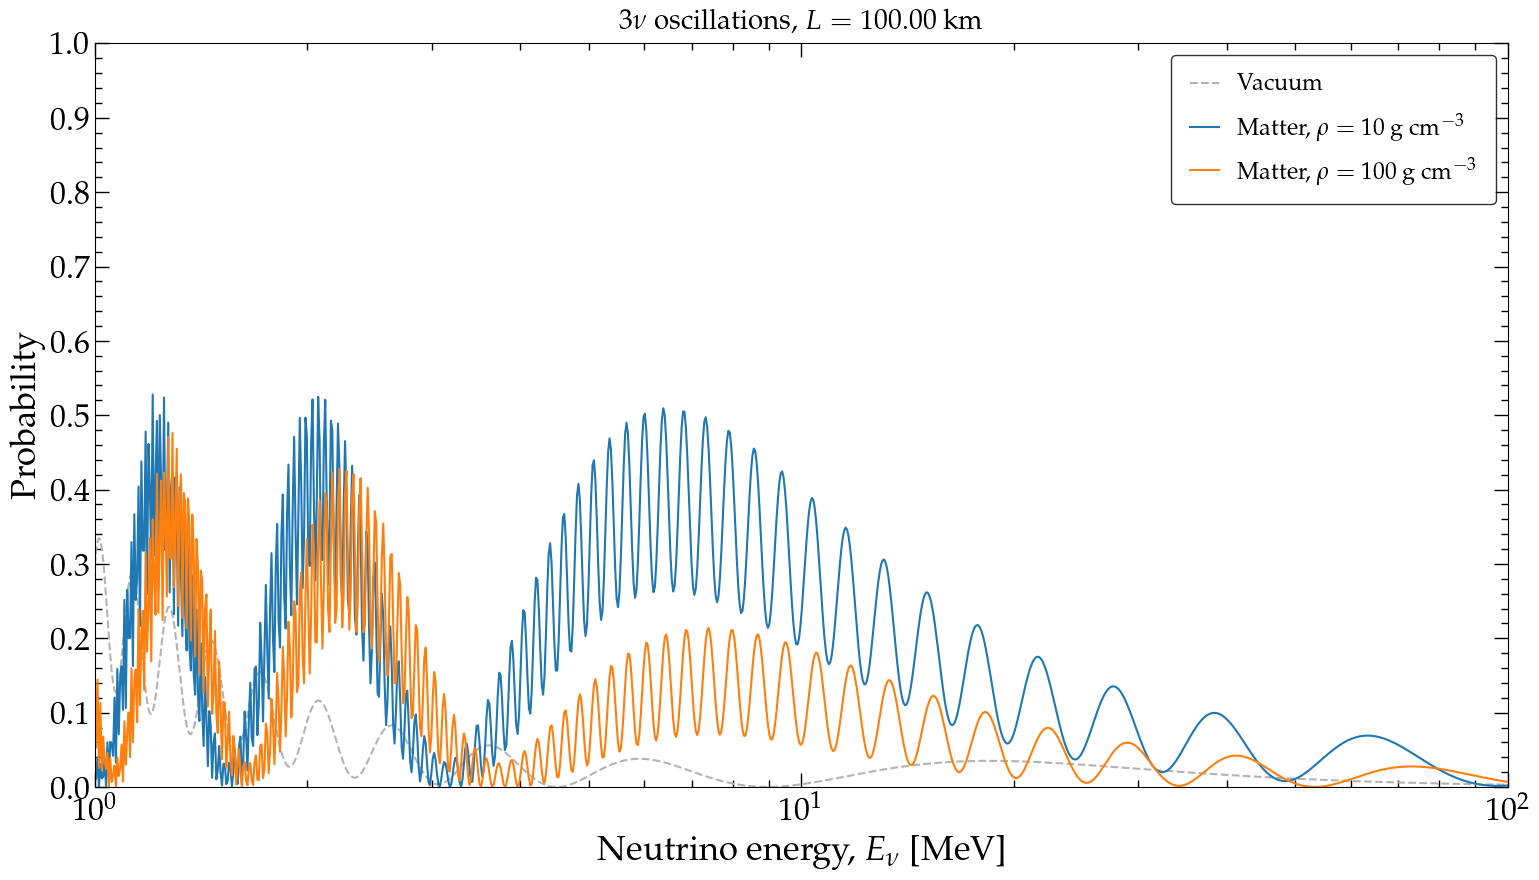

In [47]:
nu_i, nu_f = gd.NUE, gd.NUMU
npts = 1000
energy_arr = np.logspace(0.0, 2.0, npts) # [MeV]
baseline = 100.*gd.UNIT_KM # 100 km natural units [eV^{-1}]
rho_lo, rho_hi = 10*gd.UNIT_G_PER_CM3, 100*gd.UNIT_G_PER_CM3 # 10 and 100 g cm^{-3} in natural units [eV^4]

prob_3nu_matt_const_lo_vs_energy = oscprob.osc_prob_3nu_matter_constant_density(gd.UNIT_MEV*energy_arr, baseline, 
                                                                                rho=rho_lo, nu_i=nu_i, nu_f=nu_f, nubar=True)
prob_3nu_matt_const_hi_vs_energy = oscprob.osc_prob_3nu_matter_constant_density(gd.UNIT_MEV*energy_arr, baseline, 
                                                                                rho=rho_hi, nu_i=nu_i, nu_f=nu_f, nubar=True)

# This gives the same result, but it is less efficient (calling osc_prob_3nu_matter_constant_density has an overhead):
# prob_3nu_matt_const_lo_vs_energy = [oscprob.osc_prob_3nu_matter_constant_density(s12, s23, s13, dCP, D21, D31, energy, baseline,
#                                                                                  rho=rho_lo, nubar=True)[nu_i][nu_f] 
#                                     for energy in gd.UNIT_MEV*energy_arr]
# prob_3nu_matt_const_hi_vs_energy = [oscprob.osc_prob_3nu_matter_constant_density(s12, s23, s13, dCP, D21, D31, energy, baseline, 
#                                                                                  rho=rho_hi, nubar=True)[nu_i][nu_f] 
#                                     for energy in gd.UNIT_MEV*energy_arr]

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=[18,9])

ax.plot(energy_arr, prob_3nu_vacuum_vs_energy, label=r'Vacuum', c='0.7', ls='--')
ax.plot(energy_arr, prob_3nu_matt_const_lo_vs_energy, label=r'Matter, $\rho = $~{:.0f}'.format(rho_lo/gd.UNIT_G_PER_CM3)+r'~g~cm$^{-3}$')
ax.plot(energy_arr, prob_3nu_matt_const_hi_vs_energy, label=r'Matter, $\rho = $~{:.0f}'.format(rho_hi/gd.UNIT_G_PER_CM3)+r'~g~cm$^{-3}$')
ax.legend(fontsize=17, frameon=True, loc='upper right', handlelength=1.2, handleheight=0.7, borderpad=0.8, 
          title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)
ax.set_xlabel(r'Neutrino energy, $E_\nu$ [MeV]')
ax.set_ylabel(r'Probability')
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax.set_xlim(energy_arr[0], energy_arr[-1])
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.set_title(r'$3\nu$ oscillations, $L = $~{:.2f}~km'.format(baseline/gd.UNIT_KM), fontsize=20, pad=10)

So far, we have only computed oscillation probabilities in cases where the Hamiltonian is time-independent (or, equivalently, position-independent), *i.e.*, in vacuum and in matter with uniform density.  As we pointed out earlier, in these cases only the first term of the Magnus expansion is nonzero, and so the problem reduces to a simple one.  

Where Mag$\nu$s really shows its power and flexibility is when computing oscillation probabilities for time- or position-*dependent* Hamiltonians.  

Let's illustrate this first for a matter density profile that an exponentially falling as a function of distance, *e.g.*, like inside the Sun.

We can no longer use the pre-defined functions for oscillations in vacuum or constant-density matter (`osc_prob_3nu_matter_vacuum` and `osc_prob_3nu_matter_constant_density`), but we need to define our own Hamiltonians.  We do this by calling `hamiltonian_3nu_matter` with different profiles of matter potential.

### A note on speed: let your Hamiltonian take an array

The Hamiltonians defined below are written so that they work whether they are
handed a single position or a whole array of them. That is worth doing, and it
is invisible unless someone points it out.

`osc_prob` samples the Hamiltonian at every quadrature node of every slab --
often a few hundred positions for a single probability, and the adaptive
refinement repeats that at each level. So it first tries one vectorized call,
`H_func(array_of_positions)`, and uses the result if it has the right shape and
agrees with a scalar spot-check. If that fails, it falls back to calling the
function once per position: correct, but measured **4.6x slower** here
(7.8 ms against 1.7 ms per call), for bit-identical output.

Nothing about a scalar-only Hamiltonian looks wrong, which is why it is easy to
sit on the slow path indefinitely -- these notebooks did, for years. Since
version 1.0.0 the fallback raises `magnus.magnus.ScalarHamiltonianWarning` once
per session and names the fix.

In practice there is usually nothing to do: write the position dependence with
NumPy and it vectorizes by itself. `matter.VCC_func`,
`earth.density_matter_func_prem` and the `hamiltonian_*_matter` builders all
accept arrays, so an expression like

```python
def H_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep \
        + hamiltonians.hamiltonian_3nu_matter(VCC_exp_density(l, num_density_e_center, l_scale))
```

is already array-capable as written. The two things that break it are a Python
`if` on the position (use `np.where`) and a call to `float()` or `math.exp`
(use the NumPy equivalent). Where a matrix has to be built by hand, index the
potential with `[..., None, None]` so one value per position becomes a stack of
matrices:

```python
e00 = np.diag([1.0, 0.0, 0.0])
VCC[..., None, None]*e00        # (npts, 3, 3), not an error
```

A Hamiltonian that ignores its argument entirely -- constant density -- is
detected separately and costs nothing either way.

In [48]:
# H_vac_energy_indep is the vacuum Hamiltonian without the multiplicative (1/E) factor.  Since this part will not change anymore in our
# examples below, we compute it once and save it.  (Note: in this case, we could have used the function `osc_prob_3nu_matter_vacuum` to
# compute probabilities, but we choose to compute them from scratch, as the other cases.)
H_vac_energy_indep = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31) # [eV^2]
def H_vac(energy):
    return (1/energy)*H_vac_energy_indep # [eV]

# In matter: exponentially falling density profile: num_density_e_center * e^{-l/l_scale}
num_density_e_center = 10*gd.N_AV/gd.UNIT_CM3 # Central electron number density (10*N_Av cm^{-3}, converted to eV^3) [eV^3]
l_scale = 100.0 # [km]
def num_density_e_exp(l, num_density_e_center, l_scale):
    return num_density_e_center*np.exp(-(l/gd.UNIT_KM)/l_scale) # [eV^3]
def VCC_exp_density(l, num_density_e_center, l_scale):
    return matter.VCC_func(l, lambda r: num_density_e_exp(r, num_density_e_center, l_scale)) # [eV]
def H_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_3nu_matter(VCC_exp_density(l, num_density_e_center, l_scale))

Let's first fix the baseline to 500 km and compute the $\nu_e \to \nu_e$ survival probability.  We call `osc_prob` to compute the probabilities, like before, and pass `verbose = 2` to see the full output:

In [49]:
nu_i, nu_f = gd.NUE, gd.NUE
baseline  = 5.e2 # [km]
oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, baseline*gd.UNIT_KM, verbose=2)[nu_i][nu_f]

Parameters passed to function magnus.osc_prob in this run:
   H_func = <lambda>
   t_ini = 0
   t_fin = 2533865000000.0
   n_slabs = 1
   n_tpts_per_slab = 2
   t_slab_edges = None
   magnus_exp_order = 4
   n_jobs = 1
   integration_method = gl
   rtol = 0.001
   atol = 0.001
   growth_factor_n_slabs = 1.5
   growth_factor_n_tpts_per_slab = 1.0
   max_num_loops = 50
   min_n_slabs = 1
   max_n_slabs = 20000
   min_n_tpts_per_slab = 2
   max_n_tpts_per_slab = 2
   validate_input = True
   save_log = False
   filename_log = ./out.log
   new_recursion_limit = 5000
   verbose = 2

Running loops until requested rtol and atol are achieved:
   Loop #1:
      magnus_exp_order = 4
      n_slabs = 333
      n_tpts_per_slab = 2
   Loop #2:
      magnus_exp_order = 4
      n_slabs = 500
      n_tpts_per_slab = 2
   Requested tolerance achieved (for fixed magnus_exp_order = 4): rtol = 0.001, atol = 0.001.



/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

0.8815391601200597

By default, `osc_prob` uses fourth-order Magnus expansion (`magnus_exp_order = 4`) and returns the probability with a relative tolerance of `rtol = 1e-3` and an absolute tolerance of `atol = 1e-3`.  These values are sufficient for most purposes, but the user can change them if they so wish.

Let's see how the probability changes with the order of the expansion (we loosen the target tolerance so that the order, rather than the adaptive refinement, is what limits the answer).

One limit is worth knowing about here.  The default integrator, `integration_method = 'gl'`, is a set of Gauss-Legendre *commutator-free* schemes: they are separately derived integrators rather than truncations of the Magnus recursion, so they exist only up to order 6, not up to `gd.MAGNUS_EXP_ORDER_MAX = 10`.  Asking for a higher order with `'gl'` raises a `ValueError` saying so.  The `'trapezoid'` and `'simpson'` integrators do build the terms from the recursion and go all the way to 10, at the cost of many more commutators per order.

In [50]:
# The default 'gl' integrator exists up to order 6; 'trapezoid'/'simpson' go to 10.
max_order_gl = magnus.MAGNUS_EXP_ORDER_MAX_GL

[[magnus_exp_order, oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, baseline*gd.UNIT_KM,
                                     rtol=1.e-2, atol=1.e-2, magnus_exp_order=magnus_exp_order)[nu_i][nu_f]]
 for magnus_exp_order in range(1, max_order_gl+1)]

[[1, 0.8815392327040565],
 [2, 0.8815392327040565],
 [3, 0.8815391601200597],
 [4, 0.8815391601200597],
 [5, 0.8815392375793509],
 [6, 0.8815392375793509]]

The expansion order is something *you* choose and `osc_prob` keeps fixed.  What it adapts on your behalf is the **slab count**: it partitions the baseline into progressively more subintervals, recomputing until two successive refinements agree to within `rtol`/`atol`.

This split of responsibilities is deliberate, and it is worth understanding which knob does what:

* **Order** controls how well each slab is approximated at fixed width.  Raising it helps only while the series is converging on that slab -- and the cost of a term grows roughly like $2^k$ in the number of commutators, so high order is expensive.
* **Slab count** controls the width each slab has to cover.  Because a Magnus slab is *exact* for a constant Hamiltonian no matter how much phase accumulates across it, narrowing slabs is what buys accuracy when the matter profile varies.

That is why the adaptive loop refines slabs rather than order, and why order 4 is a good default: when a result is not converging, more slabs almost always beats a higher order.  If the loop reaches `max_n_slabs` without two successive levels agreeing, it emits a `ToleranceNotAchievedWarning` rather than silently returning the last value -- note that this says convergence could not be *verified*, not that the answer is necessarily bad.

Pass `verbose = 2` to watch the refinement happen:

In [51]:
oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, baseline*gd.UNIT_KM, verbose=2,
                 rtol=1.e-3, atol=1.e-3, max_n_slabs=32)[nu_i][nu_f]

Parameters passed to function magnus.osc_prob in this run:
   H_func = <lambda>
   t_ini = 0
   t_fin = 2533865000000.0
   n_slabs = 1
   n_tpts_per_slab = 2
   t_slab_edges = None
   magnus_exp_order = 4
   n_jobs = 1
   integration_method = gl
   rtol = 0.001
   atol = 0.001
   growth_factor_n_slabs = 1.5
   growth_factor_n_tpts_per_slab = 1.0
   max_num_loops = 50
   min_n_slabs = 1
   max_n_slabs = 32
   min_n_tpts_per_slab = 2
   max_n_tpts_per_slab = 2
   validate_input = True
   save_log = False
   filename_log = ./out.log
   new_recursion_limit = 5000
   verbose = 2

Running loops until requested rtol and atol are achieved:
   Loop #1:
      magnus_exp_order = 4
      n_slabs = 32
      n_tpts_per_slab = 2



/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by more than a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators

0.8815684353108866

For most purposes a fixed `magnus_exp_order` of 3 or 4 is enough, and the slab refinement does the rest.

Internally, `osc_prob` partitions the interval from `t_ini = 0` to `t_fin = baseline` into progressively more subintervals, or slabs, computes the evolution operator in each, and takes their position-ordered product.  It repeats that with a finer partition until two successive levels agree to within `rtol` and `atol`.

The number of slabs (`n_slabs`) grows from `min_n_slabs` (default `1`), multiplied at each pass by roughly `growth_factor_n_slabs` (default `1.5`), up to `max_n_slabs`.  That ceiling is **method-dependent**: `20000` for the default `'gl'` integrator and `2000` for `'trapezoid'`/`'simpson'` (see `oscprob.MAX_N_SLABS_DEFAULT`).  The split exists because the two families cost very different amounts per slab.  The loop also stops after `max_num_loops` passes (default `50`).

The number of time points per slab (`n_tpts_per_slab`) at which the Hamiltonian is sampled to integrate it grows the same way — from `min_n_tpts_per_slab` (default `2`) to `max_n_tpts_per_slab` (default `500`), by `growth_factor_n_tpts_per_slab` (default `1.5`).  **With the default `'gl'` integrator this ladder is switched off entirely**: Gauss-Legendre collocation needs only 1-3 Hamiltonian evaluations per slab regardless, so accuracy is controlled by the slab count alone and `osc_prob` pins `n_tpts_per_slab = 2`.  These parameters matter only for `'trapezoid'` and `'simpson'`.

If we set the caps low and ask for high accuracy (`rtol = atol = 1.e-6`), `osc_prob` still returns a result, but warns that the requested tolerance could not be *verified* — at the ceiling there is no finer level left to compare against, so the check cannot be completed:

In [52]:
oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, baseline*gd.UNIT_KM, verbose=2,
                 max_n_slabs=10, max_n_tpts_per_slab=10, rtol=1.e-6, atol=1.e-6)[nu_i][nu_f]

Parameters passed to function magnus.osc_prob in this run:
   H_func = <lambda>
   t_ini = 0
   t_fin = 2533865000000.0
   n_slabs = 1
   n_tpts_per_slab = 2
   t_slab_edges = None
   magnus_exp_order = 4
   n_jobs = 1
   integration_method = gl
   rtol = 1e-06
   atol = 1e-06
   growth_factor_n_slabs = 1.5
   growth_factor_n_tpts_per_slab = 1.0
   max_num_loops = 50
   min_n_slabs = 1
   max_n_slabs = 10
   min_n_tpts_per_slab = 2
   max_n_tpts_per_slab = 2
   validate_input = True
   save_log = False
   filename_log = ./out.log
   new_recursion_limit = 5000
   verbose = 2

Running loops until requested rtol and atol are achieved:
   Loop #1:
      magnus_exp_order = 4
      n_slabs = 10
      n_tpts_per_slab = 2



/tmp/ipykernel_1365821/1077469798.py:1: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), with no two levels to compare, so convergence could not be verified by successive refinement and the returned probabilities may be inaccurate. Raise max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. If the profile has a density jump or a kink, pass t_breakpoints there as well -- a slab straddling one is never fixed by more slabs. Shown once per session.
  oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, baseline*gd.UNIT_KM, verbose=2,


0.8811797320274575

If we use the default values of these run parameters, we will achieve the high accuracy we seek:

In [53]:
oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, baseline*gd.UNIT_KM, verbose=1,
                 rtol=1.e-6, atol=1.e-6)[nu_i][nu_f]

   Requested tolerance achieved (for fixed magnus_exp_order = 4): rtol = 1e-06, atol = 1e-06.



/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

0.8815369765153962

Now let's illustrate this for two matter density profiles that vary with position: the exponentially falling density above and a Gaussian function where most of the matter is concentrated at a certain position.  We also show results for vacuum and for constant density.

In [54]:
# In matter: constant density equal to central density 
VCC_center = matter.VCC_func(0.0, lambda l: num_density_e_center) # [eV]
H_matt_const_density = hamiltonians.hamiltonian_3nu_matter(VCC_center) # [eV]
def H_const_density(energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density # [eV]

# In matter: Gaussian density profile, centered around l_central, with width l_width
num_density_e_basal = 0*gd.N_AV/gd.UNIT_CM3 # [eV^3]
num_density_e_central = 8*gd.N_AV/gd.UNIT_CM3 # [eV^3]
l_central, l_width = 300.0, 100.0 # [km]
def num_density_e_gaussian(l, num_density_e_central, l_central, l_width):
    return num_density_e_basal+num_density_e_central*np.exp( -(l/gd.UNIT_KM-l_central)**2/(2.0*l_width**2)) # [eV^3]
def VCC_gaussian_density(l, num_density_e_central, l_central, l_width):
    return matter.VCC_func(l, lambda r: num_density_e_gaussian(r, num_density_e_central, l_central, l_width)) # [eV]
def H_gaussian_density(l, energy):
    return (1/energy)*H_vac_energy_indep  \
        + hamiltonians.hamiltonian_3nu_matter(VCC_gaussian_density(l, num_density_e_central, l_central, l_width)) # [eV]

Let's first generate the $\nu_e \to \nu_e$ survival probabilities vs. baseline for a fixed energy.  We pass `n_jobs = 10` to spread the work over ten parallel jobs: these parallelize over the requested **(energy, baseline) points**, not over the slabs within one point, so they pay off exactly when there are many points to compute -- as here, with a thousand baselines.  For a single point, leave it at 1.

We also drop to third-order Magnus expansion for speed; the results do not change noticeably at this accuracy.

In [55]:
nu_i, nu_f = gd.NUE, gd.NUE

# Baselines
l_ini, l_fin = 5.e1, 1.e3 # [km]
l_npts = 1000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
energy = 10.0*gd.UNIT_MEV # [eV]

# In vacuum
print('Computing probabilities in vacuum ...\n')
prob_vac = [oscprob.osc_prob(H_vac(energy), 0.0, l*gd.UNIT_KM)[nu_i][nu_f] for l in distances]
print('   Done\n')

# In matter: constant density equal to central density 
print('Computing probabilities in matter, constant density ...\n')
prob_matt_const_density = [oscprob.osc_prob(H_const_density(energy), 0, l*gd.UNIT_KM)[nu_i][nu_f] for l in distances]
print('   Done\n')

# For vacuum and constant-density matter above, because we passed a time-independent Hamiltonian to `osc_prob`, we need not pass any other
# argument to it; internally, Magnus detects that is a time-independent case and adjusts the run parameters automatically for it (e.g.,
# sets the Magnus expansion to first-order only).  See comments above.

# For varying-density matter below, we need to pass to `osc_prob`, first, the Hamiltonian as a position-dependent function and, second,
# values for the run parameters to set the target accuracy with which to compute the probability.

# In matter: exponentially falling density profile
print('Computing probabilities in matter, exponentially falling density ...\n')
prob_matt_exp_density = [oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, l*gd.UNIT_KM,
                                          magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] 
                         for l in distances]
print('   Done\n')

# In matter: Gaussian density profile
print('Computing probabilities in matter, Gaussian density ...\n')
prob_matt_gaussian_density = [oscprob.osc_prob(lambda l: H_gaussian_density(l, energy), 0, l*gd.UNIT_KM, 
                                               magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] 
                              for l in distances]
print('   Done\n')

Computing probabilities in vacuum ...

   Done

Computing probabilities in matter, constant density ...



   Done

Computing probabilities in matter, exponentially falling density ...



   Done

Computing probabilities in matter, Gaussian density ...



   Done



Now plot the probabilities vs. distance:

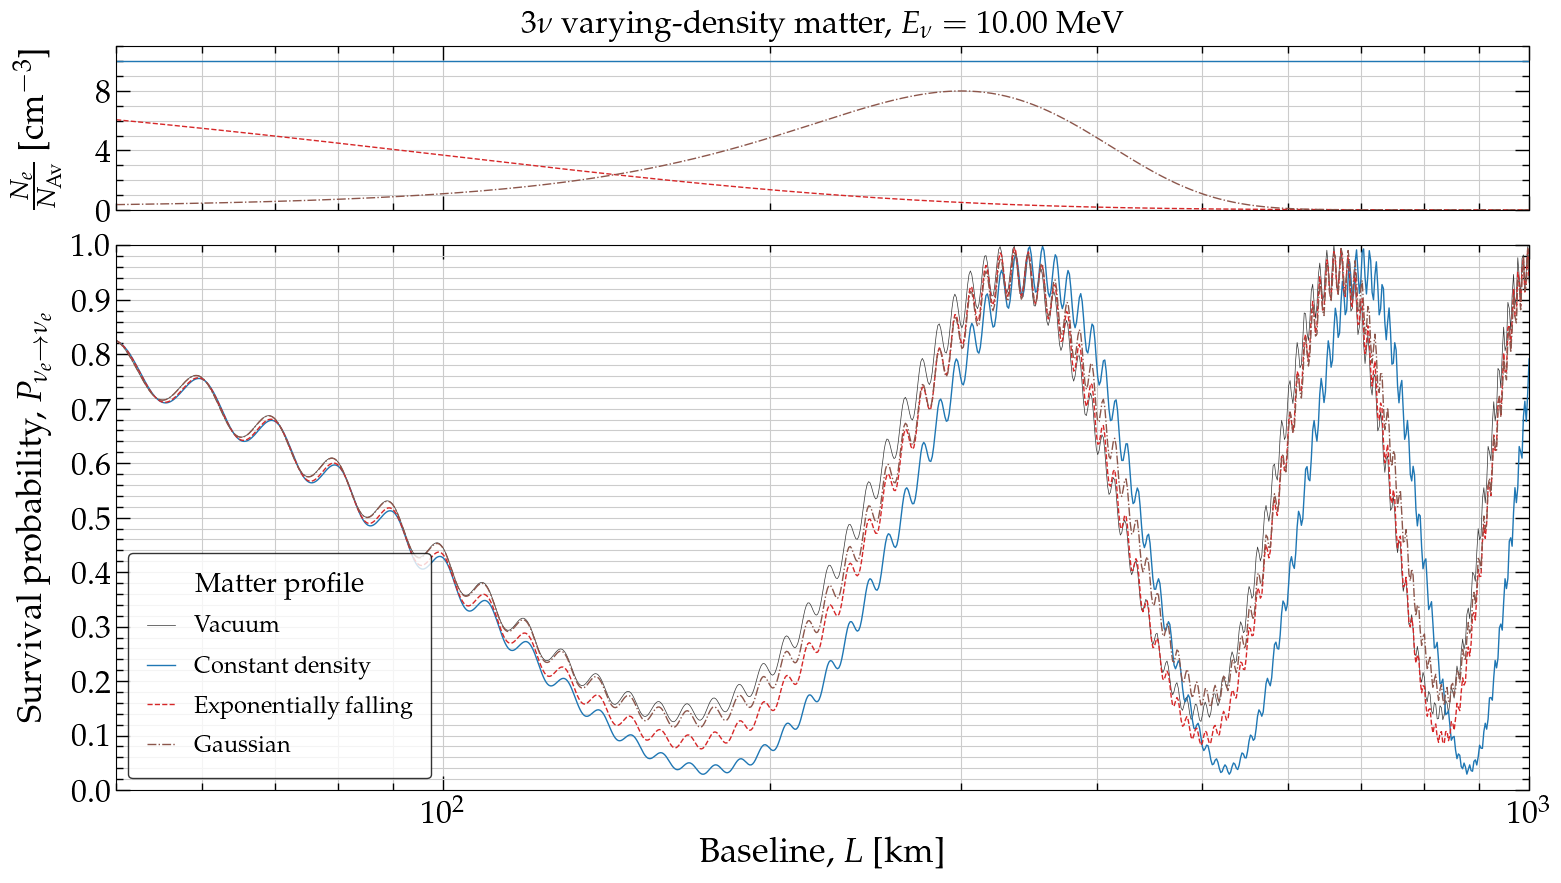

In [56]:
norm = (gd.N_AV/gd.UNIT_CM3)
fig, ax = plotting.plot_probability_with_profile(
    distances,
    [dict(y=[num_density_e_center/norm for l in distances], color='C0'),
     dict(y=[num_density_e_exp(l*gd.UNIT_KM, num_density_e_center, l_scale)/norm
             for l in distances], color='C3', ls='--'),
     dict(y=[num_density_e_gaussian(l*gd.UNIT_KM, num_density_e_central, l_central, l_width)/norm
             for l in distances], color='C5', ls='-.')],
    [[dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
      dict(y=prob_matt_const_density, label=r'Constant density', color='C0'),
      dict(y=prob_matt_exp_density, label=r'Exponentially falling', color='C3', ls='--'),
      dict(y=prob_matt_gaussian_density, label=r'Gaussian', color='C5', ls='-.')]],
    xlim=(l_ini, l_fin), profile_ylim=(0, 11),
    profile_ymajor=4, profile_yminor=1, profile_height=0.3,
    panel_ylabels=[r'Survival probability, $P_{\nu_e \to \nu_e}$'],
    xlabel=r'Baseline, $L$ [km]', title_fontsize=23,
    title=r'$3\nu$~varying-density matter, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    legend_title=r'Matter profile', legend_loc='lower left')

Let's now generate probabilities vs. energy for a fixed baseline:

In [57]:
# Energies
energy_min, energy_max = 1.e0, 1.e2 # [MeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
baseline = 1.e3*gd.UNIT_KM # 1000 km in eV^{-1} [eV^{-1}]

# In vacuum
print('Computing probabilities in vacuum ...\n')
prob_vac = [oscprob.osc_prob(H_vac(enu), 0.0, baseline)[nu_i][nu_f] for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: constant density equal to central density 
print('Computing probabilities in matter, constant density ...\n')
prob_matt_const_density = [oscprob.osc_prob(H_const_density(enu), 0, baseline)[nu_i][nu_f] for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: exponentially falling density profile
print('Computing probabilities in matter, exponentially falling density ...\n')
prob_matt_exp_density = [oscprob.osc_prob(lambda l: H_exp_density(l, enu), 0, baseline, 
                                          magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] 
                         for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: Gaussian density profile
print('Computing probabilities in matter, Gaussian density ...\n')
prob_matt_gaussian_density = [oscprob.osc_prob(lambda l: H_gaussian_density(l, enu), 0, baseline, 
                                               magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] 
                              for enu in gd.UNIT_MEV*energies]
print('   Done\n')

Computing probabilities in vacuum ...



   Done

Computing probabilities in matter, constant density ...



   Done

Computing probabilities in matter, exponentially falling density ...



/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

   Done

Computing probabilities in matter, Gaussian density ...



   Done



And plot them:

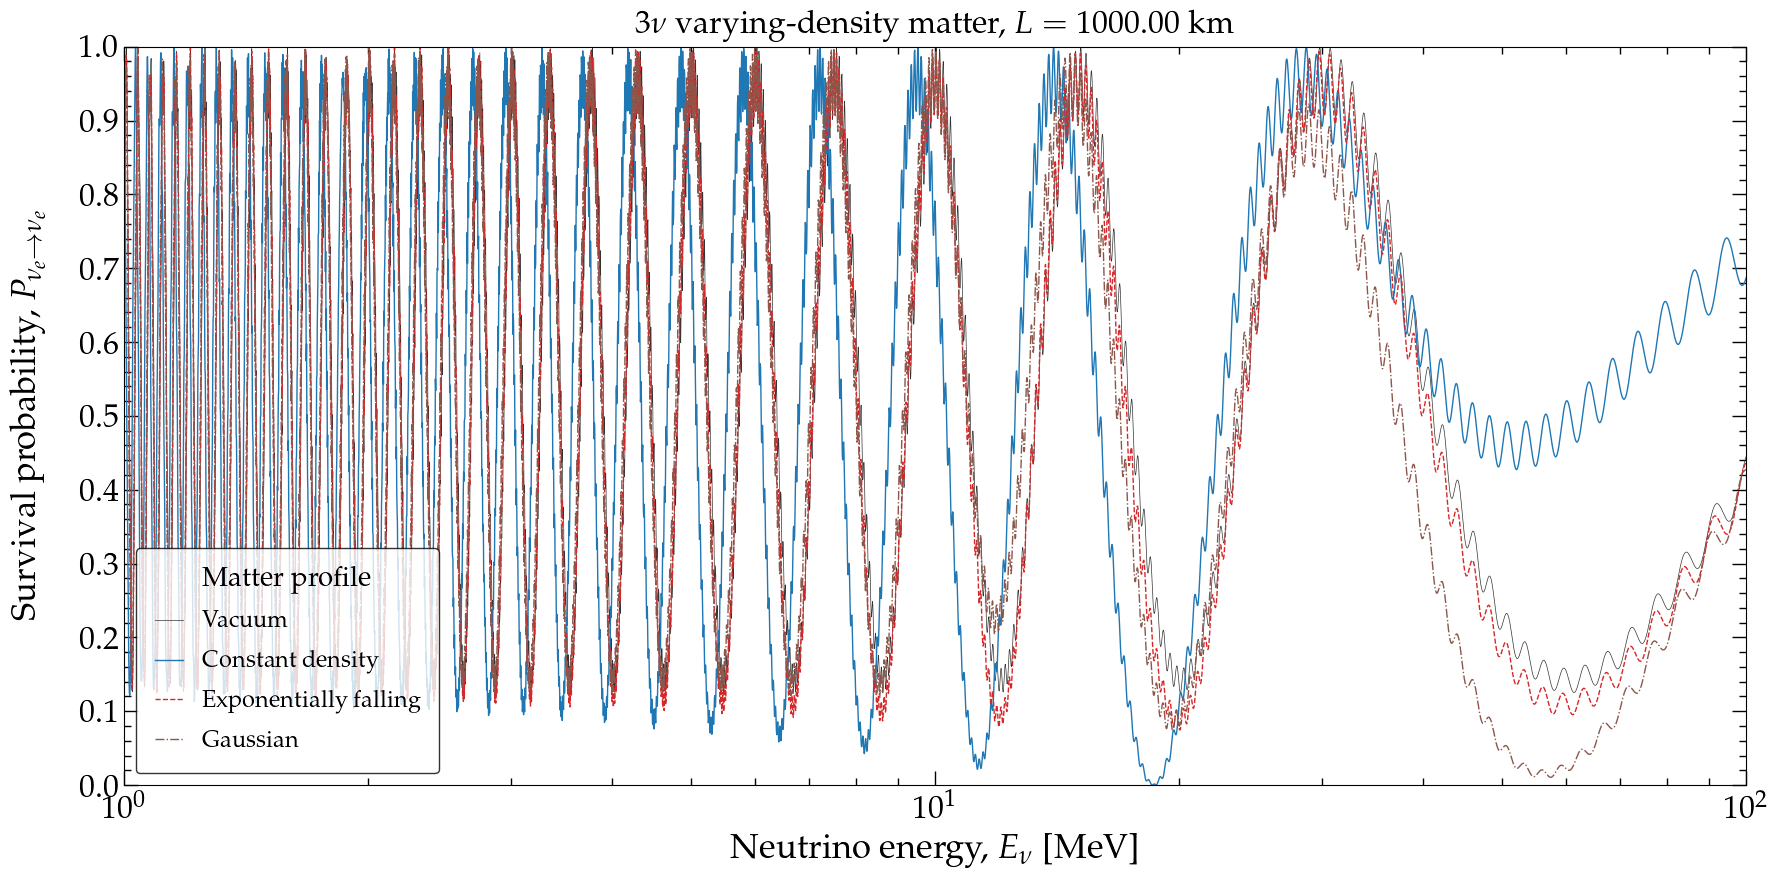

In [58]:
fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
     dict(y=prob_matt_const_density, label=r'Constant density', color='C0'),
     dict(y=prob_matt_exp_density, label=r'Exponentially falling', color='C3', ls='--'),
     dict(y=prob_matt_gaussian_density, label=r'Gaussian', color='C5', ls='-.')],
    energy_unit='MeV',
    ylabel=r'Survival probability, $P_{\nu_e \to \nu_e}$',
    xlim=(energies[0], energies[-1]), title_fontsize=23,
    title=r'$3\nu$~varying-density matter, $L = $~{:.2f}~km'.format(baseline/gd.UNIT_KM),
    legend_title=r'Matter profile', legend_loc='lower left')

Finally, let's  show one example of beyond-the-Standard-Model neutrino physics in the form of non-standard neutrino-matter interactions (NSI).  These interactions introduce a new matter contribution to the Hamiltonian,
\begin{equation}
 H_{3\nu}^{\rm NSI}
 = 
 V_{\rm CC}
 \left(
  \begin{array}{ccc}
   \epsilon_{ee}         & \epsilon_{e\mu}         & \epsilon_{e\tau} \\
   \epsilon_{e\mu}^\ast  & \epsilon_{\mu\mu}       & \epsilon_{\mu\tau} \\
   \epsilon_{e\tau}^\ast & \epsilon_{\mu\tau}^\ast & \epsilon_{\tau\tau}
  \end{array}
 \right) \;,
\end{equation}
where the coefficients $\epsilon_{\alpha\beta}$ set the strength of the interaction.  Their values are set by experiment.  We set them to their predefined values from `globaldefs`, but they can be set to any value.

In [59]:
eps_ee, eps_em, eps_et, eps_mm, eps_mt, eps_tt = gd.EPS_3
print(gd.EPS_3)

[0.06, -0.06, 0.0, 1.2, 0.0, 0.0]


We test NSI using the exponentially falling matter density.  We increase the distance scale (`l_scale`) beyond which the matter profile exponentially decays, in order for the matter effects to be more evident.  We also define the Hamiltonian with NSI matter effects:

In [60]:
l_scale = 1.e3 # [km]

def num_density_e_exp(l, num_density_e_center, l_scale):
    return num_density_e_center*np.exp(-(l/gd.UNIT_KM)/l_scale) # [eV^3]
def VCC_exp_density(l, num_density_e_center, l_scale):
    return matter.VCC_func(l, lambda r: num_density_e_exp(r, num_density_e_center, l_scale)) # [eV]

# In matter: exponentially falling density profile
def H_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_3nu_matter(VCC_exp_density(l, num_density_e_center, l_scale))
    
# In matter: exponentially falling density profile
def H_exp_density_nsi(l, energy): 
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_3nu_nsi(
        VCC_exp_density(l, num_density_e_center, l_scale),
        eps_ee, eps_em, eps_et, eps_mm, eps_mt, eps_tt)

Now we generate the probabilities vs. distance.  We choose a higher energy than before to make the matter contribution more dominant relative to the vacuum one:

In [61]:
nu_i, nu_f = gd.NUE, gd.NUE

# Baselines
l_ini, l_fin = 5.e1, 1.e3 # [km]
l_npts = 1000 
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 10.0*gd.UNIT_MEV # [eV]

# In vacuum
print('Computing probabilities in vacuum ...\n')
prob_vac = [oscprob.osc_prob(H_vac(energy), 0.0, l*gd.UNIT_KM)[nu_i][nu_f] for l in distances]
print('   Done\n')

# In matter: constant density equal to central density 
print('Computing probabilities in matter, constant density ...\n')
prob_matt_const_density = [oscprob.osc_prob(H_const_density(energy), 0, l*gd.UNIT_KM)[nu_i][nu_f] for l in distances]
print('   Done\n')

# In matter: exponentially falling density profile
print('Computing probabilities in matter, exponentially falling density ...\n')
prob_matt_exp_density = [oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, l*gd.UNIT_KM, 
                                          magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] 
                         for l in distances]
print('   Done\n')

# In matter: exponentially falling density profile with NSI
print('Computing probabilities in matter, exponentially falling density with NSI ...\n')
prob_matt_exp_density_nsi = [oscprob.osc_prob(lambda l: H_exp_density_nsi(l, energy), 0, l*gd.UNIT_KM, 
                                              magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] 
                             for l in distances]
print('   Done\n')

Computing probabilities in vacuum ...

   Done

Computing probabilities in matter, constant density ...

   Done

Computing probabilities in matter, exponentially falling density ...



   Done

Computing probabilities in matter, exponentially falling density with NSI ...



/home/mbustamante/Research/magnus/src/magnus/magnus.py:414: ScalarHamiltonianWarning: magnus: the Hamiltonian could not be evaluated for several positions at once, so it is being called one position at a time. This is correct but slower -- measured 4.6x on a 3nu exponential-density profile -- because the engine samples the Hamiltonian at every quadrature node of every slab, and the adaptive refinement repeats that at each level. To take the fast path, write H_func so that it accepts an array of positions and returns a stack of matrices: turn the position dependence into NumPy operations and broadcast the matrix part, e.g. 'VCC[..., None, None]*e00' instead of 'VCC*e00'. A Hamiltonian that ignores its argument is detected separately and never triggers this. Shown once per session.
  _, mode = _evaluate_A(A, times, None)


   Done



And plot them:

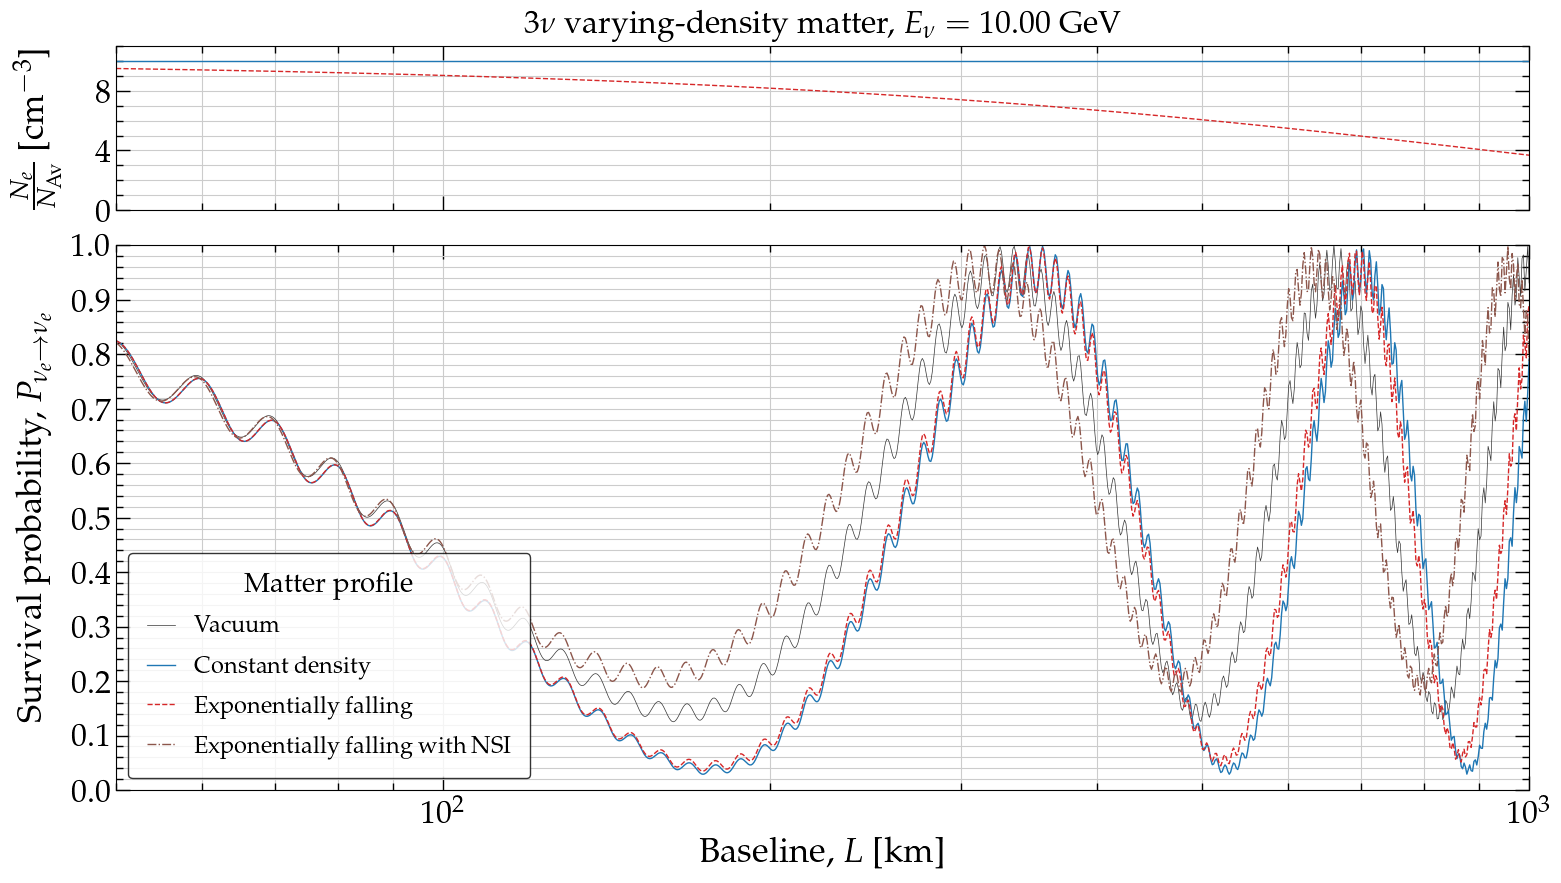

In [62]:
norm = (gd.N_AV/gd.UNIT_CM3)
fig, ax = plotting.plot_probability_with_profile(
    distances,
    [dict(y=[num_density_e_center/norm for l in distances], color='C0'),
     dict(y=[num_density_e_exp(l*gd.UNIT_KM, num_density_e_center, l_scale)/norm
             for l in distances], color='C3', ls='--')],
    [[dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
      dict(y=prob_matt_const_density, label=r'Constant density', color='C0'),
      dict(y=prob_matt_exp_density, label=r'Exponentially falling', color='C3', ls='--'),
      dict(y=prob_matt_exp_density_nsi, label=r'Exponentially falling with NSI',
           color='C5', ls='-.')]],
    xlim=(l_ini, l_fin), profile_ylim=(0, 11),
    profile_ymajor=4, profile_yminor=1, profile_height=0.3,
    panel_ylabels=[r'Survival probability, $P_{\nu_e \to \nu_e}$'],
    xlabel=r'Baseline, $L$ [km]', title_fontsize=23, ylabel_labelpad=25,
    title=r'$3\nu$~varying-density matter, $E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_MEV),
    legend_title=r'Matter profile', legend_loc='lower left')

Finally, let's generate probabilities vs. energy for a fixed baseline:

In [63]:
# Energies
energy_min, energy_max = 1.e0, 1.e2 # [MeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
baseline = 5.e2*gd.UNIT_KM # 500 km in eV^{-1} [eV^{-1}]

# In vacuum
print('Computing probabilities in vacuum ...\n')
prob_vac = [oscprob.osc_prob(H_vac(enu), 0.0, baseline)[nu_i][nu_f] for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: constant density equal to central density 
print('Computing probabilities in matter, constant density ...\n')
prob_matt_const_density = [oscprob.osc_prob(H_const_density(enu), 0, baseline)[nu_i][nu_f] for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: exponentially falling density profile
print('Computing probabilities in matter, exponentially falling density ...\n')
prob_matt_exp_density = [oscprob.osc_prob(lambda l: H_exp_density(l, enu), 0, baseline, 
                                          magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] 
                         for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: exponentially falling density profile
print('Computing probabilities in matter, exponentially falling density with NSI ...\n')
prob_matt_exp_density_nsi = [oscprob.osc_prob(lambda l: H_exp_density_nsi(l, enu), 0, baseline, 
                                              magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] 
                             for enu in gd.UNIT_MEV*energies]
print('   Done\n')

Computing probabilities in vacuum ...



   Done

Computing probabilities in matter, constant density ...



   Done

Computing probabilities in matter, exponentially falling density ...



/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

   Done

Computing probabilities in matter, exponentially falling density with NSI ...



/home/mbustamante/Research/magnus/src/magnus/magnus.py:414: ScalarHamiltonianWarning: magnus: the Hamiltonian could not be evaluated for several positions at once, so it is being called one position at a time. This is correct but slower -- measured 4.6x on a 3nu exponential-density profile -- because the engine samples the Hamiltonian at every quadrature node of every slab, and the adaptive refinement repeats that at each level. To take the fast path, write H_func so that it accepts an array of positions and returns a stack of matrices: turn the position dependence into NumPy operations and broadcast the matrix part, e.g. 'VCC[..., None, None]*e00' instead of 'VCC*e00'. A Hamiltonian that ignores its argument is detected separately and never triggers this. Shown once per session.
  _, mode = _evaluate_A(A, times, None)


   Done



And plot them:

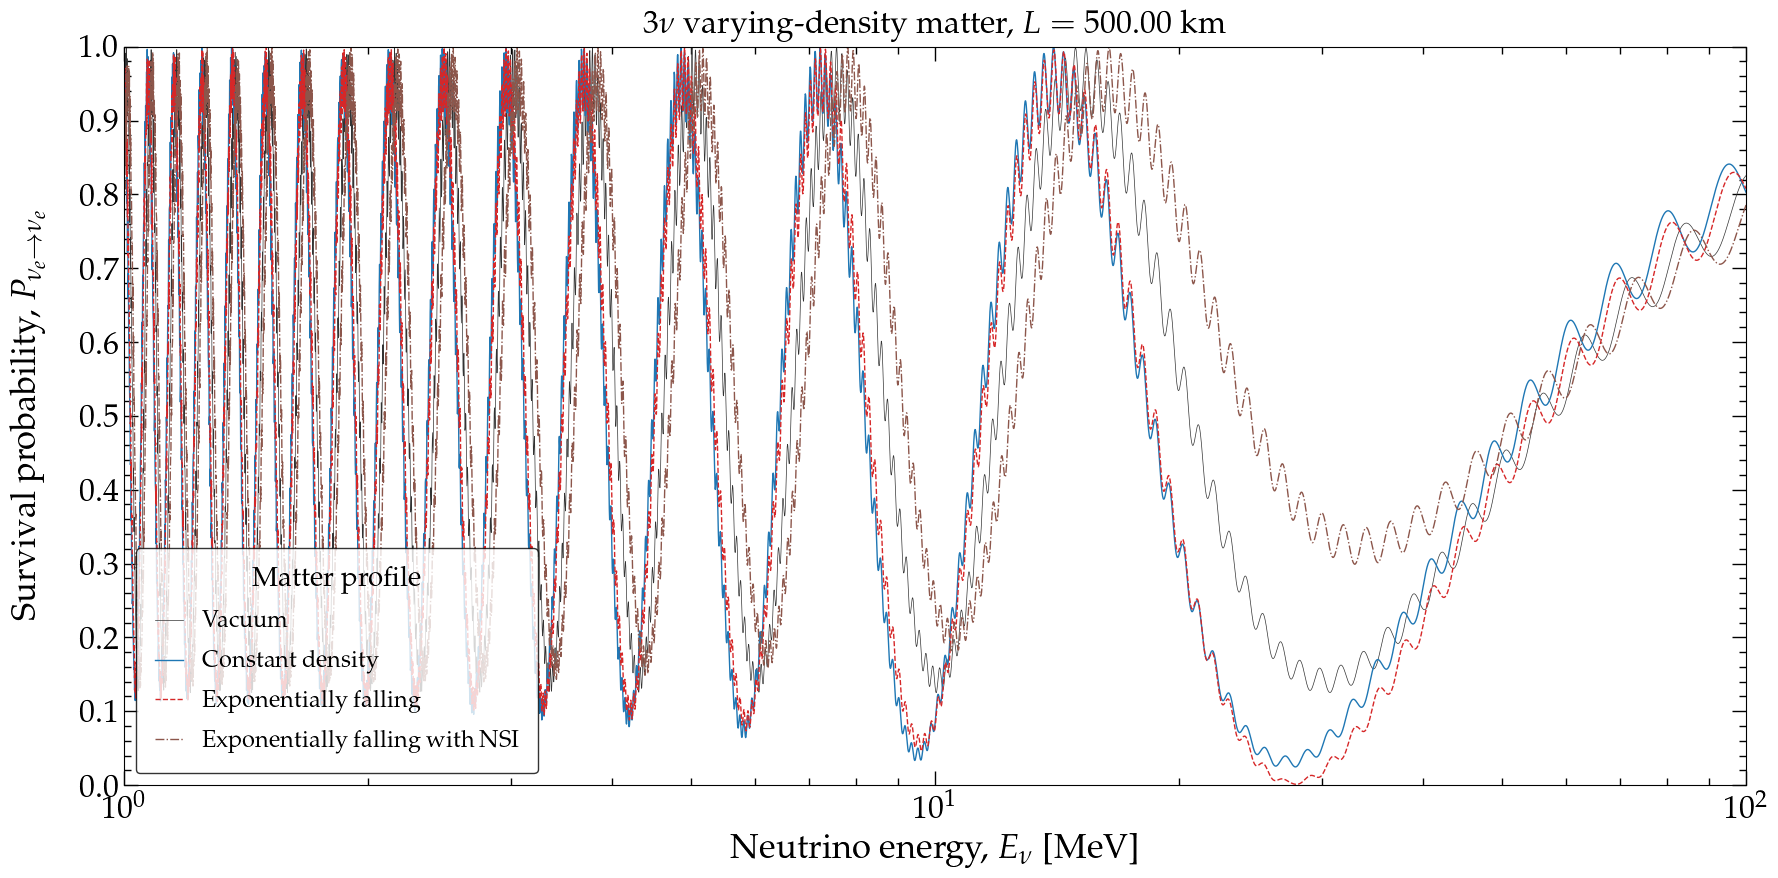

In [64]:
fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
     dict(y=prob_matt_const_density, label=r'Constant density', color='C0'),
     dict(y=prob_matt_exp_density, label=r'Exponentially falling', color='C3', ls='--'),
     dict(y=prob_matt_exp_density_nsi, label=r'Exponentially falling with NSI',
          color='C5', ls='-.')],
    energy_unit='MeV',
    ylabel=r'Survival probability, $P_{\nu_e \to \nu_e}$',
    xlim=(energies[0], energies[-1]), title_fontsize=23,
    title=r'$3\nu$~varying-density matter, $L = $~{:.2f}~km'.format(baseline/gd.UNIT_KM),
    legend_title=r'Matter profile', legend_loc='lower left')

---

**Next:** [Two-neutrino probabilities](02_magnus_2nu_vacuum_matter.ipynb) --- vacuum, constant and varying density, castle wall, Earth and Sun  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)